# Week 6 Capstone Project
## End-to-End Airbnb Price Intelligence and Prediction System

### YuvaIntern Virtual Data Science with Python Internship

This notebook implements an end-to-end Data Science pipeline covering:

- Data acquisition
- Data validation
- Data preprocessing
- Exploratory Data Analysis
- Feature engineering
- Unsupervised learning
- Classical machine learning
- Deep learning
- Model evaluation
- Error analysis
- Comparative analysis
- Data-driven insights and recommendations

**Dataset:** Airbnb Open Data  
**Target Variable:** Price  
**Problem Type:** Regression

In [1]:
# ============================================================
# 01. PROJECT CONFIGURATION & ENVIRONMENT VALIDATION
# ============================================================

from __future__ import annotations

import os
import sys
import platform
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import tensorflow as tf

from sklearn import __version__ as sklearn_version

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("=" * 72)
print("WEEK 6 CAPSTONE — ENVIRONMENT VALIDATION")
print("=" * 72)

print(f"Python       : {sys.version.split()[0]}")
print(f"Platform     : {platform.platform()}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Scikit-learn : {sklearn_version}")
print(f"TensorFlow   : {tf.__version__}")

print("\nTensorFlow devices:")
for device in tf.config.list_physical_devices():
    print(f"  • {device}")

print("\n" + "=" * 72)
print("Environment initialized successfully.")
print("=" * 72)

WEEK 6 CAPSTONE — ENVIRONMENT VALIDATION
Python       : 3.13.15
Platform     : Linux-6.6.122+-x86_64-with-glibc2.39
NumPy        : 2.1.3
Pandas       : 2.2.3
Scikit-learn : 1.6.1
TensorFlow   : 2.20.0

TensorFlow devices:
  • PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')

Environment initialized successfully.


In [2]:
# ============================================================
# 01. PROJECT CONFIGURATION & ENVIRONMENT VALIDATION
# ============================================================

from __future__ import annotations

import os
import sys
import platform
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import tensorflow as tf

from sklearn import __version__ as sklearn_version

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Display configuration
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("=" * 72)
print("WEEK 6 CAPSTONE — ENVIRONMENT VALIDATION")
print("=" * 72)

print(f"Python       : {sys.version.split()[0]}")
print(f"Platform     : {platform.platform()}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Scikit-learn : {sklearn_version}")
print(f"TensorFlow   : {tf.__version__}")

print("\nTensorFlow devices:")
for device in tf.config.list_physical_devices():
    print(f"  • {device}")

print("\n" + "=" * 72)
print("Environment initialized successfully.")
print("=" * 72)

WEEK 6 CAPSTONE — ENVIRONMENT VALIDATION
Python       : 3.13.15
Platform     : Linux-6.6.122+-x86_64-with-glibc2.39
NumPy        : 2.1.3
Pandas       : 2.2.3
Scikit-learn : 1.6.1
TensorFlow   : 2.20.0

TensorFlow devices:
  • PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')

Environment initialized successfully.


In [3]:
# ============================================================
# 02. PROJECT CONFIGURATION
# ============================================================

PROJECT_NAME = "Airbnb Price Intelligence and Prediction System"

DATASET_NAME = "Cleaned_Data.csv"

TARGET = "price"

RANDOM_STATE = 42

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

ARTIFACT_DIR = Path("/content/capstone_artifacts")
MODEL_DIR = ARTIFACT_DIR / "models"
FIGURE_DIR = ARTIFACT_DIR / "figures"
RESULT_DIR = ARTIFACT_DIR / "results"

for directory in (
    ARTIFACT_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    RESULT_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT_NAME}")
print(f"Target  : {TARGET}")
print(f"Seed    : {RANDOM_STATE}")
print(f"Artifacts directory: {ARTIFACT_DIR}")

Project : Airbnb Price Intelligence and Prediction System
Target  : price
Seed    : 42
Artifacts directory: /content/capstone_artifacts


In [4]:
# ============================================================
# 02. PROJECT CONFIGURATION
# ============================================================

PROJECT_NAME = "Airbnb Price Intelligence and Prediction System"

DATASET_NAME = "Cleaned_Data.csv"

TARGET = "price"

RANDOM_STATE = 42

TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20

ARTIFACT_DIR = Path("/content/capstone_artifacts")
MODEL_DIR = ARTIFACT_DIR / "models"
FIGURE_DIR = ARTIFACT_DIR / "figures"
RESULT_DIR = ARTIFACT_DIR / "results"

for directory in (
    ARTIFACT_DIR,
    MODEL_DIR,
    FIGURE_DIR,
    RESULT_DIR,
):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT_NAME}")
print(f"Target  : {TARGET}")
print(f"Seed    : {RANDOM_STATE}")
print(f"Artifacts directory: {ARTIFACT_DIR}")

Project : Airbnb Price Intelligence and Prediction System
Target  : price
Seed    : 42
Artifacts directory: /content/capstone_artifacts


In [8]:
## ============================================================
# 03. DATASET CONFIGURATION
# ============================================================

from pathlib import Path

DATASET_NAME = "Airbnb_Open_Data.csv"
DATA_PATH = Path("/content") / DATASET_NAME

print(f"Dataset path: {DATA_PATH}")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}"
    )

print("✓ Dataset located successfully.")

Dataset path: /content/Airbnb_Open_Data.csv
✓ Dataset located successfully.


In [9]:
# ============================================================
# 04. RAW DATA LOADING
# ============================================================

df_raw = pd.read_csv(DATA_PATH)

print("=" * 72)
print("RAW DATASET LOADED")
print("=" * 72)

print(f"Shape       : {df_raw.shape}")
print(f"Rows        : {len(df_raw):,}")
print(f"Columns     : {df_raw.shape[1]}")

display(df_raw.head())

RAW DATASET LOADED
Shape       : (102599, 26)
Rows        : 102,599
Columns     : 26


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,country code,instant_bookable,cancellation_policy,room type,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.6475,-73.9724,United States,US,False,strict,Private room,"2,020.0000",$966,$193,10.0000,9.0000,10/19/2021,0.2100,4.0000,6.0000,286.0000,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.7536,-73.9838,United States,US,False,moderate,Entire home/apt,"2,007.0000",$142,$28,30.0000,45.0000,5/21/2022,0.3800,4.0000,2.0000,228.0000,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.8090,-73.9419,United States,US,True,flexible,Private room,"2,005.0000",$620,$124,3.0000,0.0000,NaN,NaN,5.0000,1.0000,352.0000,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.6851,-73.9598,United States,US,True,moderate,Entire home/apt,"2,005.0000",$368,$74,30.0000,270.0000,7/5/2019,4.6400,4.0000,1.0000,322.0000,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.7985,-73.9440,United States,US,False,moderate,Entire home/apt,"2,009.0000",$204,$41,10.0000,9.0000,11/19/2018,0.1000,3.0000,1.0000,289.0000,"Please no smoking in the house, porch or on th...",NaN


In [10]:
# ============================================================
# 05. RAW DATA QUALITY AUDIT
# ============================================================

def generate_data_quality_report(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Generate a structured data-quality report for the input dataframe.
    """

    report = pd.DataFrame({
        "dtype": dataframe.dtypes.astype(str),
        "missing_count": dataframe.isna().sum(),
        "missing_pct": dataframe.isna().mean().mul(100),
        "unique_count": dataframe.nunique(dropna=True),
        "memory_usage_mb": (
            dataframe.memory_usage(deep=True)
            .div(1024 ** 2)
        )
    })

    return report.sort_values(
        by="missing_count",
        ascending=False
    )


quality_report = generate_data_quality_report(df_raw)

print("=" * 80)
print("RAW DATA QUALITY REPORT")
print("=" * 80)

display(
    quality_report.style.format({
        "missing_pct": "{:.2f}%",
        "memory_usage_mb": "{:.3f}"
    })
)

print(f"\nDataset shape       : {df_raw.shape}")
print(f"Duplicate rows      : {df_raw.duplicated().sum():,}")
print(f"Total missing cells : {df_raw.isna().sum().sum():,}")
print(
    f"Memory usage        : "
    f"{df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

RAW DATA QUALITY REPORT


,dtype,missing_count,missing_pct,unique_count,memory_usage_mb
license,object,102597.000000,100.00%,1.000000,3.131
house_rules,object,52131.000000,50.81%,1976.000000,19.667
last review,object,15893.000000,15.49%,2477.000000,5.265
reviews per month,float64,15879.000000,15.48%,1016.000000,0.783
country,object,532.000000,0.52%,1.000000,6.051
availability 365,float64,448.000000,0.44%,438.000000,0.783
minimum nights,float64,409.000000,0.40%,153.000000,0.783
host name,object,406.000000,0.40%,13190.000000,5.400
review rate number,float64,326.000000,0.32%,5.000000,0.783
calculated host listings count,float64,319.000000,0.31%,78.000000,0.783



Dataset shape       : (102599, 26)
Duplicate rows      : 541
Total missing cells : 190,769
Memory usage        : 104.69 MB


In [11]:
# ============================================================
# 06. COLUMN TYPE PROFILING
# ============================================================

dtype_profile = pd.DataFrame({
    "column": df_raw.columns,
    "dtype": df_raw.dtypes.astype(str).values,
    "unique_values": [
        df_raw[column].nunique(dropna=True)
        for column in df_raw.columns
    ]
})

display(dtype_profile)

,column,dtype,unique_values
0,id,int64,102058
1,NAME,object,61281
2,host id,int64,102057
3,host_identity_verified,object,2
4,host name,object,13190
5,neighbourhood group,object,7
6,neighbourhood,object,224
7,lat,float64,21991
8,long,float64,17774
9,country,object,1


In [12]:
# ============================================================
# 07. NUMERICAL & CATEGORICAL PROFILE
# ============================================================

numeric_columns = df_raw.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df_raw.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical columns:")
print(*numeric_columns, sep="\n")

print("\nCategorical/object columns:")
print(*categorical_columns, sep="\n")

Numerical columns:
id
host id
lat
long
Construction year
minimum nights
number of reviews
reviews per month
review rate number
calculated host listings count
availability 365

Categorical/object columns:
NAME
host_identity_verified
host name
neighbourhood group
neighbourhood
country
country code
instant_bookable
cancellation_policy
room type
price
service fee
last review
house_rules
license


In [13]:
# ============================================================
# 08. RAW VALUE INSPECTION
# ============================================================

for column in ["price", "service fee", "minimum nights"]:
    if column in df_raw.columns:
        print(f"\n{'=' * 60}")
        print(f"{column.upper()}")
        print("=" * 60)
        print(df_raw[column].head(10).to_list())


PRICE
['$966 ', '$142 ', '$620 ', '$368 ', '$204 ', '$577 ', '$71 ', '$1,060 ', '$1,018 ', '$291 ']

SERVICE FEE
['$193 ', '$28 ', '$124 ', '$74 ', '$41 ', '$115 ', '$14 ', '$212 ', '$204 ', '$58 ']

MINIMUM NIGHTS
[10.0, 30.0, 3.0, 30.0, 10.0, 3.0, 45.0, 45.0, 2.0, 2.0]


In [14]:
# ============================================================
# 09. CREATE CLEANING WORKSPACE
# ============================================================

df_clean = df_raw.copy(deep=True)

print(f"Raw dataframe shape     : {df_raw.shape}")
print(f"Cleaning dataframe shape: {df_clean.shape}")

Raw dataframe shape     : (102599, 26)
Cleaning dataframe shape: (102599, 26)


In [15]:
# ============================================================
# 10. COLUMN NAME STANDARDIZATION
# ============================================================

def normalize_column_name(column: str) -> str:
    return (
        str(column)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


df_clean.columns = [
    normalize_column_name(column)
    for column in df_clean.columns
]

print("Standardized columns:")
print(df_clean.columns.tolist())

Standardized columns:
['id', 'name', 'host_id', 'host_identity_verified', 'host_name', 'neighbourhood_group', 'neighbourhood', 'lat', 'long', 'country', 'country_code', 'instant_bookable', 'cancellation_policy', 'room_type', 'construction_year', 'price', 'service_fee', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'review_rate_number', 'calculated_host_listings_count', 'availability_365', 'house_rules', 'license']


In [16]:
# ============================================================
# 11. NUMERIC FIELD NORMALIZATION
# ============================================================

monetary_columns = [
    "price",
    "service_fee"
]

for column in monetary_columns:
    if column in df_clean.columns:
        df_clean[column] = (
            df_clean[column]
            .astype("string")
            .str.replace(r"[$,]", "", regex=True)
            .str.strip()
            .replace({"": pd.NA, "nan": pd.NA})
        )

        df_clean[column] = pd.to_numeric(
            df_clean[column],
            errors="coerce"
        )


numeric_candidates = [
    "lat",
    "long",
    "construction_year",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "review_rate_number",
    "calculated_host_listings_count",
    "availability_365"
]

for column in numeric_candidates:
    if column in df_clean.columns:
        df_clean[column] = pd.to_numeric(
            df_clean[column],
            errors="coerce"
        )

print("Numeric normalization completed.")

Numeric normalization completed.


In [17]:
# ============================================================
# 12. STRUCTURAL COLUMN REMOVAL
# ============================================================

structural_columns = [
    "unnamed:_0",
    "index"
]

columns_to_drop = [
    column
    for column in structural_columns
    if column in df_clean.columns
]

df_clean.drop(
    columns=columns_to_drop,
    inplace=True
)

print("Removed structural columns:")
print(columns_to_drop)

print(f"\nCurrent shape: {df_clean.shape}")

Removed structural columns:
[]

Current shape: (102599, 26)


In [18]:
# ============================================================
# 13. ANALYTICAL COLUMN SELECTION
# ============================================================

ANALYTICAL_COLUMNS = [
    "id",
    "name",
    "host_id",
    "host_identity_verified",
    "host_name",
    "neighbourhood_group",
    "neighbourhood",
    "lat",
    "long",
    "country",
    "country_code",
    "instant_bookable",
    "cancellation_policy",
    "room_type",
    "construction_year",
    "price",
    "service_fee",
    "minimum_nights",
    "number_of_reviews",
]

missing_columns = sorted(
    set(ANALYTICAL_COLUMNS) - set(df_clean.columns)
)

if missing_columns:
    raise KeyError(
        f"Required columns are missing: {missing_columns}"
    )

df_clean = df_clean.loc[:, ANALYTICAL_COLUMNS].copy()

print(f"Raw shape        : {df_raw.shape}")
print(f"Analytical shape : {df_clean.shape}")

Raw shape        : (102599, 26)
Analytical shape : (102599, 19)


In [19]:
# ============================================================
# 14. CRITICAL FIELD VALIDATION
# ============================================================

CRITICAL_COLUMNS = [
    "price",
    "neighbourhood_group",
    "neighbourhood",
    "lat",
    "long",
    "room_type",
    "minimum_nights",
    "number_of_reviews",
]

before_missing_filter = len(df_clean)

df_clean = df_clean.dropna(
    subset=CRITICAL_COLUMNS
).copy()

removed_missing = (
    before_missing_filter - len(df_clean)
)

print(f"Rows before missing-value filter : {before_missing_filter:,}")
print(f"Rows removed                     : {removed_missing:,}")
print(f"Rows remaining                   : {len(df_clean):,}")

Rows before missing-value filter : 102,599
Rows removed                     : 886
Rows remaining                   : 101,713


In [20]:
# ============================================================
# 15. DUPLICATE REMOVAL
# ============================================================

before_duplicates = len(df_clean)

df_clean = df_clean.drop_duplicates(
    keep="first"
).copy()

removed_duplicates = (
    before_duplicates - len(df_clean)
)

print(f"Rows before duplicate removal : {before_duplicates:,}")
print(f"Duplicate rows removed        : {removed_duplicates:,}")
print(f"Rows remaining                : {len(df_clean):,}")

Rows before duplicate removal : 101,713
Duplicate rows removed        : 532
Rows remaining                : 101,181


In [21]:
# ============================================================
# 16. CATEGORICAL STANDARDIZATION
# ============================================================

CATEGORY_STANDARDIZATION = {
    "neighbourhood_group": {
        "brookln": "Brooklyn",
        "manhatan": "Manhattan",
    }
}

for column, replacements in CATEGORY_STANDARDIZATION.items():
    if column in df_clean.columns:
        df_clean[column] = df_clean[column].replace(
            replacements
        )

print("Category standardization completed.")

print("\nNeighbourhood groups:")
print(
    df_clean["neighbourhood_group"]
    .value_counts()
)

Category standardization completed.

Neighbourhood groups:
neighbourhood_group
Manhattan        43177
Brooklyn         41305
Queens           13078
Bronx             2679
Staten Island      942
Name: count, dtype: int64


In [22]:
# ============================================================
# 17. NUMERICAL RANGE VALIDATION
# ============================================================

invalid_minimum_nights = (
    df_clean["minimum_nights"] <= 0
)

invalid_count = invalid_minimum_nights.sum()

print(
    f"Invalid minimum_nights observations: "
    f"{invalid_count:,}"
)

if invalid_count:
    print("\nInvalid values:")
    display(
        df_clean.loc[
            invalid_minimum_nights,
            ["minimum_nights", "price"]
        ].head(20)
    )

Invalid minimum_nights observations: 13

Invalid values:


,minimum_nights,price
176,-10.0000,1155
352,-5.0000,73
398,-1.0000,779
421,-10.0000,874
441,-12.0000,920
478,-2.0000,410
525,-3.0000,413
42446,"-1,223.0000",1200
42500,-365.0000,711
42538,-200.0000,85


In [23]:
before_range_filter = len(df_clean)

df_clean = df_clean.loc[
    df_clean["minimum_nights"] > 0
].copy()

removed_invalid_nights = (
    before_range_filter - len(df_clean)
)

print(
    f"Rows removed for invalid minimum_nights: "
    f"{removed_invalid_nights:,}"
)

print(
    f"Rows remaining: {len(df_clean):,}"
)

Rows removed for invalid minimum_nights: 13
Rows remaining: 101,168


In [24]:
# ============================================================
# 18. TARGET VALIDATION
# ============================================================

invalid_price = (
    ~np.isfinite(df_clean["price"])
    | (df_clean["price"] <= 0)
)

print(
    f"Invalid price observations: "
    f"{invalid_price.sum():,}"
)

if invalid_price.any():
    display(
        df_clean.loc[
            invalid_price,
            ["price"]
        ].head(20)
    )

df_clean = df_clean.loc[
    ~invalid_price
].copy()

Invalid price observations: 0


In [25]:
# ============================================================
# 19. FINAL CLEANING VALIDATION
# ============================================================

assert df_clean["price"].notna().all()
assert df_clean["minimum_nights"].notna().all()
assert (df_clean["minimum_nights"] > 0).all()
assert np.isfinite(df_clean["price"]).all()

assert df_clean.duplicated().sum() == 0

assert not (
    df_clean["neighbourhood_group"]
    .astype(str)
    .str.lower()
    .isin(["brookln", "manhatan"])
).any()

print("=" * 72)
print("FINAL CLEANING VALIDATION")
print("=" * 72)

print(f"Final dataset shape : {df_clean.shape}")
print(f"Missing cells       : {df_clean.isna().sum().sum():,}")
print(f"Duplicate rows      : {df_clean.duplicated().sum():,}")
print(
    f"Negative minimum nights : "
    f"{(df_clean['minimum_nights'] < 0).sum():,}"
)

print("\n✓ All critical validation checks passed.")

FINAL CLEANING VALIDATION
Final dataset shape : (101168, 19)
Missing cells       : 2,130
Duplicate rows      : 0
Negative minimum nights : 0

✓ All critical validation checks passed.


In [26]:
# ============================================================
# 20. EXPORT CLEAN DATA
# ============================================================

CLEAN_DATA_PATH = (
    ARTIFACT_DIR / "airbnb_capstone_cleaned.csv"
)

df_clean.to_csv(
    CLEAN_DATA_PATH,
    index=False
)

print(
    f"Clean dataset saved to:\n"
    f"{CLEAN_DATA_PATH}"
)

Clean dataset saved to:
/content/capstone_artifacts/airbnb_capstone_cleaned.csv


In [31]:
# ============================================================
# 21A. RESIDUAL MISSING-VALUE DIAGNOSTIC
# ============================================================

remaining_missing = (
    df_clean.isna()
    .sum()
    .loc[lambda s: s.gt(0)]
    .sort_values(ascending=False)
)

if remaining_missing.empty:
    print("No missing values remain.")
else:
    diagnostic = pd.DataFrame({
        "missing_count": remaining_missing,
        "missing_pct": (
            remaining_missing
            .div(len(df_clean))
            .mul(100)
        )
    })

    display(
        diagnostic.style.format({
            "missing_pct": "{:.3f}%"
        })
    )

,missing_count,missing_pct
name,239,0.236%
service_fee,239,0.236%
construction_year,192,0.190%


In [32]:
# ============================================================
# 21B. COMPLETE MISSING-VALUE TREATMENT
# ============================================================

# Fields retained for descriptive/contextual purposes
categorical_fields = [
    "name",
    "host_identity_verified",
    "host_name",
    "neighbourhood_group",
    "neighbourhood",
    "country",
    "country_code",
    "instant_bookable",
    "cancellation_policy",
    "room_type",
]

numeric_fields = [
    "lat",
    "long",
    "construction_year",
    "price",
    "service_fee",
    "minimum_nights",
    "number_of_reviews",
]

for column in categorical_fields:
    if column in df_clean.columns:
        df_clean[column] = (
            df_clean[column]
            .astype("string")
            .fillna("Unknown")
            .str.strip()
        )

for column in numeric_fields:
    if column in df_clean.columns:
        df_clean[column] = pd.to_numeric(
            df_clean[column],
            errors="coerce"
        )

        df_clean[column] = df_clean[column].fillna(
            df_clean[column].median()
        )

print("Complete missing-value treatment applied.")

Complete missing-value treatment applied.


In [33]:
# ============================================================
# 21C. REMOVE NON-ANALYTICAL IDENTIFIERS
# ============================================================

identifier_columns = [
    "id",
    "host_id",
]

df_clean.drop(
    columns=[
        column
        for column in identifier_columns
        if column in df_clean.columns
    ],
    inplace=True
)

print("Non-analytical identifier columns removed.")

Non-analytical identifier columns removed.


In [35]:
# ============================================================
# 22. POST-TRANSFORMATION DUPLICATE DIAGNOSTIC
# ============================================================

duplicate_mask = df_clean.duplicated(
    keep=False
)

duplicate_count = int(
    df_clean.duplicated().sum()
)

duplicate_rows = int(
    duplicate_mask.sum()
)

print(f"Duplicate records beyond first occurrence : {duplicate_count:,}")
print(f"Rows belonging to duplicate groups         : {duplicate_rows:,}")

if duplicate_rows:
    display(
        df_clean.loc[
            duplicate_mask
        ].sort_values(
            by=[
                "neighbourhood_group",
                "neighbourhood",
                "price"
            ]
        ).head(20)
    )

Duplicate records beyond first occurrence : 3,374
Rows belonging to duplicate groups         : 6,669


,name,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,country_code,instant_bookable,cancellation_policy,room_type,construction_year,price,service_fee,minimum_nights,number_of_reviews
26226,Luxury Tiny house • Ohka,unconfirmed,Journee,Bronx,Allerton,40.8614,-73.8643,United States,US,True,strict,Entire home/apt,"2,007.0000",144,29,2.0000,95.0000
83390,Luxury Tiny house • Ohka,unconfirmed,Journee,Bronx,Allerton,40.8614,-73.8643,United States,US,True,strict,Entire home/apt,"2,007.0000",144,29,2.0000,95.0000
33568,#ERROR!,verified,William,Bronx,Allerton,40.8601,-73.8630,United States,US,False,strict,Private room,"2,020.0000",864,173,1.0000,30.0000
96501,#ERROR!,verified,William,Bronx,Allerton,40.8601,-73.8630,United States,US,False,strict,Private room,"2,020.0000",864,173,1.0000,30.0000
33251,♥♥♥ Entire House with Backyard & Superfast WiF...,verified,William,Bronx,Allerton,40.8616,-73.8623,United States,US,True,moderate,Entire home/apt,"2,021.0000",1114,223,2.0000,31.0000
96184,♥♥♥ Entire House with Backyard & Superfast WiF...,verified,William,Bronx,Allerton,40.8616,-73.8623,United States,US,True,moderate,Entire home/apt,"2,021.0000",1114,223,2.0000,31.0000
35865,Akouaba,verified,Adama,Bronx,Belmont,40.8527,-73.8863,United States,US,True,flexible,Private room,"2,011.0000",972,194,2.0000,51.0000
98798,Akouaba,verified,Adama,Bronx,Belmont,40.8527,-73.8863,United States,US,True,flexible,Private room,"2,011.0000",972,194,2.0000,51.0000
14468,Cozy and bright bedroom with a queen size bed.,unconfirmed,Donald,Bronx,Bronxdale,40.8532,-73.8651,United States,US,True,moderate,Private room,"2,008.0000",192,38,2.0000,83.0000
84290,Cozy and bright bedroom with a queen size bed.,unconfirmed,Donald,Bronx,Bronxdale,40.8532,-73.8651,United States,US,True,moderate,Private room,"2,008.0000",192,38,2.0000,83.0000


In [36]:
# ============================================================
# 23. FINAL DEDUPLICATION
# ============================================================

before_final_dedup = len(df_clean)

df_clean = df_clean.drop_duplicates(
    keep="first"
).reset_index(drop=True)

removed_final_duplicates = (
    before_final_dedup - len(df_clean)
)

print(
    f"Rows before final deduplication : "
    f"{before_final_dedup:,}"
)

print(
    f"Duplicate rows removed          : "
    f"{removed_final_duplicates:,}"
)

print(
    f"Rows after final deduplication  : "
    f"{len(df_clean):,}"
)

Rows before final deduplication : 101,168
Duplicate rows removed          : 3,374
Rows after final deduplication  : 97,794


In [37]:
# ============================================================
# 24. FINAL CAPSTONE DATA QUALITY GATE
# ============================================================

quality_conditions = {
    "No missing values":
        df_clean.isna().sum().sum() == 0,

    "No duplicate rows":
        df_clean.duplicated().sum() == 0,

    "Positive prices":
        (df_clean["price"] > 0).all(),

    "Positive minimum nights":
        (df_clean["minimum_nights"] > 0).all(),

    "Finite prices":
        np.isfinite(
            df_clean["price"].to_numpy()
        ).all(),

    "Finite minimum nights":
        np.isfinite(
            df_clean["minimum_nights"].to_numpy()
        ).all(),
}

for condition, passed in quality_conditions.items():
    print(f"{'✓' if passed else '✗'} {condition}")

if not all(quality_conditions.values()):
    failed = [
        condition
        for condition, passed in quality_conditions.items()
        if not passed
    ]

    raise AssertionError(
        f"Quality gate failed: {failed}"
    )

print("\n" + "=" * 72)
print("FINAL DATA QUALITY GATE PASSED")
print("=" * 72)

print(f"Rows    : {len(df_clean):,}")
print(f"Columns : {df_clean.shape[1]}")

✓ No missing values
✓ No duplicate rows
✓ Positive prices
✓ Positive minimum nights
✓ Finite prices
✓ Finite minimum nights

FINAL DATA QUALITY GATE PASSED
Rows    : 97,794
Columns : 17


In [38]:
# ============================================================
# 25. EXPORT FINAL CAPSTONE DATASET
# ============================================================

FINAL_CLEAN_PATH = (
    ARTIFACT_DIR / "airbnb_capstone_final_clean.csv"
)

df_clean.to_csv(
    FINAL_CLEAN_PATH,
    index=False
)

print(
    f"Final cleaned dataset saved to:\n"
    f"{FINAL_CLEAN_PATH}"
)

Final cleaned dataset saved to:
/content/capstone_artifacts/airbnb_capstone_final_clean.csv


In [39]:
# ============================================================
# 26. FEATURE ENGINEERING WORKSPACE
# ============================================================

analysis_df = df_clean.copy(deep=True)

print(f"Base analytical dataset: {analysis_df.shape}")

Base analytical dataset: (97794, 17)


In [40]:
# ============================================================
# 26.1. BINARY FEATURE ENGINEERING
# ============================================================

analysis_df["host_verified_flag"] = (
    analysis_df["host_identity_verified"]
    .str.upper()
    .eq("VERIFIED")
    .astype("int8")
)

analysis_df["instant_bookable_flag"] = (
    analysis_df["instant_bookable"]
    .astype(str)
    .str.lower()
    .eq("true")
    .astype("int8")
)

In [41]:
# ============================================================
# 26.2. SKEWNESS-ROBUST COUNT FEATURES
# ============================================================

analysis_df["log_minimum_nights"] = np.log1p(
    analysis_df["minimum_nights"]
)

analysis_df["log_number_of_reviews"] = np.log1p(
    analysis_df["number_of_reviews"]
)

print(
    analysis_df[
        [
            "minimum_nights",
            "log_minimum_nights",
            "number_of_reviews",
            "log_number_of_reviews",
        ]
    ].describe().round(3)
)

       minimum_nights  log_minimum_nights  number_of_reviews  \
count     97,794.0000         97,794.0000        97,794.0000   
mean           8.1750              1.5800            27.4440   
std           30.6840              0.9390            49.6210   
min            1.0000              0.6930             0.0000   
25%            2.0000              1.0990             1.0000   
50%            3.0000              1.3860             7.0000   
75%            5.0000              1.7920            30.0000   
max        5,645.0000              8.6390         1,024.0000   

       log_number_of_reviews  
count            97,794.0000  
mean                  2.2070  
std                   1.5620  
min                   0.0000  
25%                   0.6930  
50%                   2.0790  
75%                   3.4340  
max                   6.9320  


In [42]:
# ============================================================
# 26.3. GEOGRAPHIC INTERACTION FEATURE
# ============================================================

analysis_df["lat_long_interaction"] = (
    analysis_df["lat"] * analysis_df["long"]
)

In [43]:
# ============================================================
# 27. FEATURE INVENTORY
# ============================================================

engineered_features = [
    "host_verified_flag",
    "instant_bookable_flag",
    "log_minimum_nights",
    "log_number_of_reviews",
    "lat_long_interaction",
]

feature_inventory = pd.DataFrame({
    "feature": engineered_features,
    "dtype": [
        analysis_df[feature].dtype
        for feature in engineered_features
    ],
    "missing": [
        analysis_df[feature].isna().sum()
        for feature in engineered_features
    ],
})

display(feature_inventory)

assert (
    feature_inventory["missing"].sum() == 0
)

print("\n✓ Engineered feature validation passed.")

,feature,dtype,missing
0,host_verified_flag,int8,0
1,instant_bookable_flag,int8,0
2,log_minimum_nights,float64,0
3,log_number_of_reviews,float64,0
4,lat_long_interaction,float64,0



✓ Engineered feature validation passed.


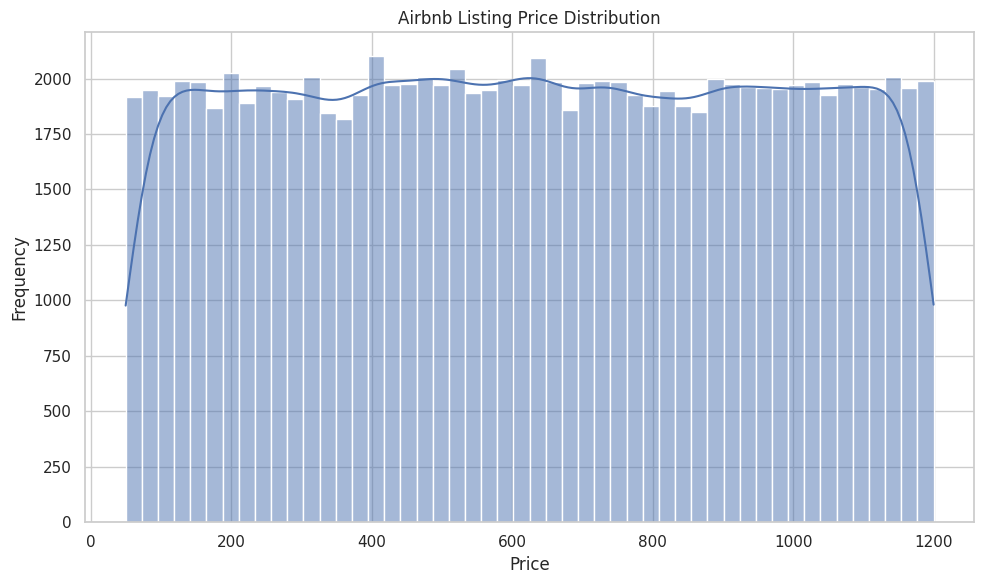

In [44]:
# ============================================================
# 28. PRICE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(
    data=analysis_df,
    x="price",
    bins=50,
    kde=True,
    ax=ax,
)

ax.set_title("Airbnb Listing Price Distribution")
ax.set_xlabel("Price")
ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

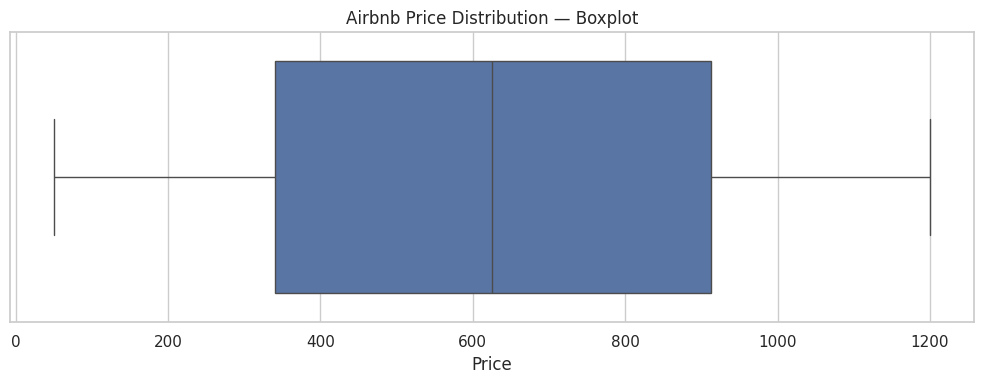

In [45]:
# ============================================================
# 28.1. PRICE OUTLIER VIEW
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))

sns.boxplot(
    data=analysis_df,
    x="price",
    ax=ax,
)

ax.set_title("Airbnb Price Distribution — Boxplot")
ax.set_xlabel("Price")

plt.tight_layout()
plt.show()

In [46]:
# ============================================================
# 29. PRICE BY NEIGHBOURHOOD GROUP
# ============================================================

neighbourhood_price = (
    analysis_df
    .groupby("neighbourhood_group")["price"]
    .agg(
        listing_count="size",
        mean_price="mean",
        median_price="median",
        std_price="std",
    )
    .sort_values(
        "median_price",
        ascending=False
    )
)

display(
    neighbourhood_price.round(2)
)

,listing_count,mean_price,median_price,std_price
neighbourhood_group,,,,
Bronx,2592,626.9700,630.0000,324.4800
Staten Island,908,627.0700,629.0000,326.0300
Brooklyn,39870,626.7400,627.0000,331.9400
Queens,12657,629.5200,627.0000,333.4000
Manhattan,41767,622.8900,621.0000,331.6300


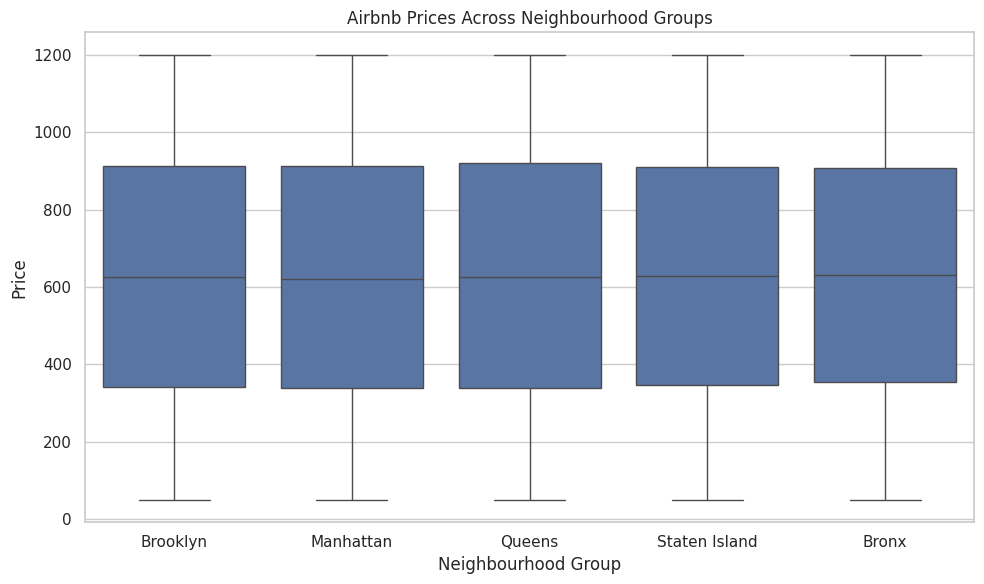

In [47]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=analysis_df,
    x="neighbourhood_group",
    y="price",
    ax=ax,
)

ax.set_title("Airbnb Prices Across Neighbourhood Groups")
ax.set_xlabel("Neighbourhood Group")
ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

In [48]:
# ============================================================
# 30. PRICE BY ROOM TYPE
# ============================================================

room_price = (
    analysis_df
    .groupby("room_type")["price"]
    .agg(
        listing_count="size",
        mean_price="mean",
        median_price="median",
    )
    .sort_values(
        "median_price",
        ascending=False
    )
)

display(
    room_price.round(2)
)

,listing_count,mean_price,median_price
room_type,,,
Shared room,2124,632.3700,648.0000
Hotel room,113,668.4200,643.0000
Entire home/apt,51296,625.3500,625.0000
Private room,44261,625.1500,623.0000


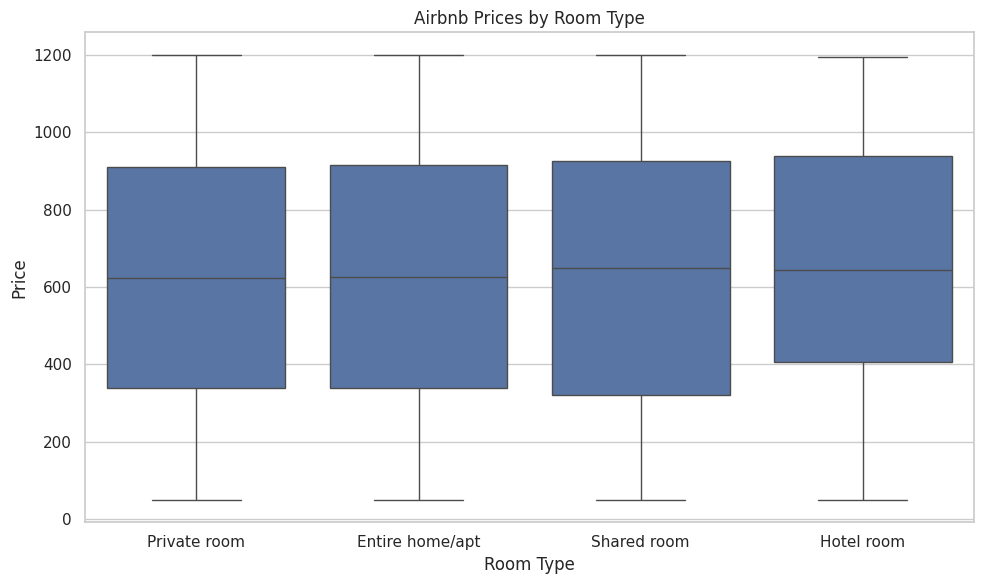

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=analysis_df,
    x="room_type",
    y="price",
    ax=ax,
)

ax.set_title("Airbnb Prices by Room Type")
ax.set_xlabel("Room Type")
ax.set_ylabel("Price")

plt.tight_layout()
plt.show()

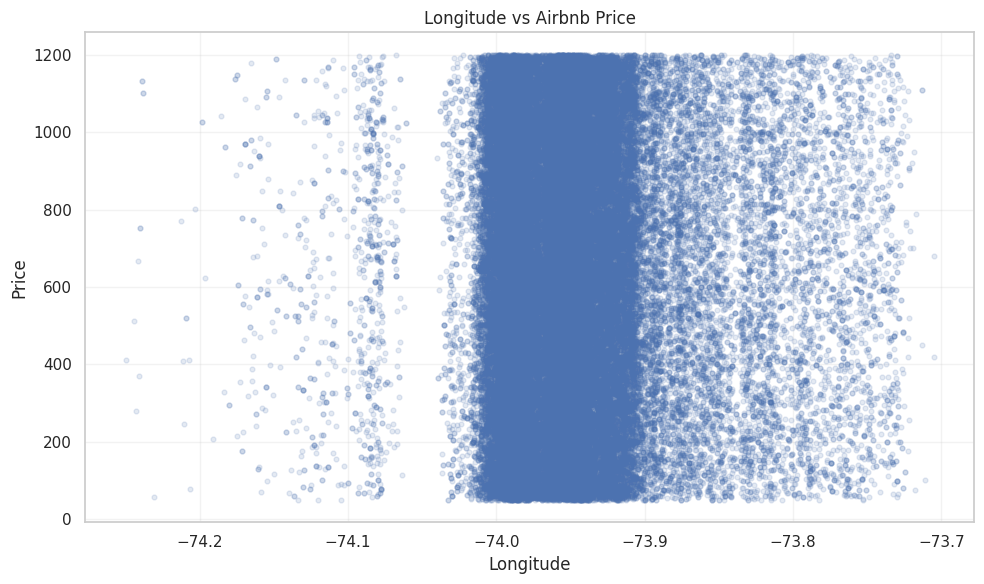

In [50]:
# ============================================================
# 31. LONGITUDE VS PRICE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    analysis_df["long"],
    analysis_df["price"],
    alpha=0.15,
    s=12,
)

ax.set_title("Longitude vs Airbnb Price")
ax.set_xlabel("Longitude")
ax.set_ylabel("Price")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

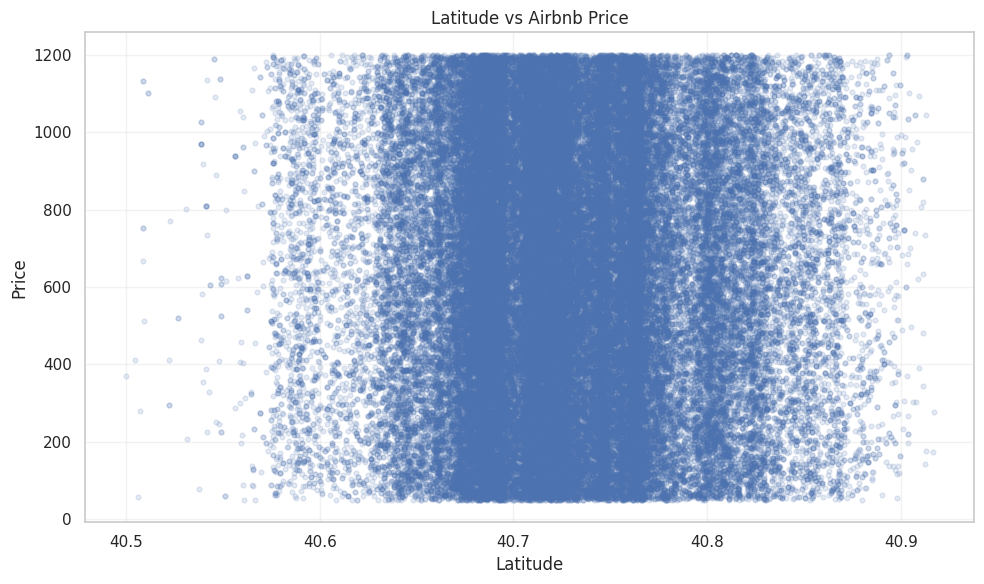

In [51]:
# ============================================================
# 31.1. LATITUDE VS PRICE
# ============================================================

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    analysis_df["lat"],
    analysis_df["price"],
    alpha=0.15,
    s=12,
)

ax.set_title("Latitude vs Airbnb Price")
ax.set_xlabel("Latitude")
ax.set_ylabel("Price")

ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# 32. NUMERICAL CORRELATION ANALYSIS
# ============================================================

numerical_for_correlation = [
    "price",
    "service_fee",
    "lat",
    "long",
    "construction_year",
    "minimum_nights",
    "number_of_reviews",
    "host_verified_flag",
    "instant_bookable_flag",
    "log_minimum_nights",
    "log_number_of_reviews",
    "lat_long_interaction",
]

correlation_matrix = (
    analysis_df[numerical_for_correlation]
    .corr(numeric_only=True)
)

display(
    correlation_matrix.round(3)
)

,price,service_fee,lat,long,construction_year,minimum_nights,number_of_reviews,host_verified_flag,instant_bookable_flag,log_minimum_nights,log_number_of_reviews,lat_long_interaction
price,1.0000,0.9990,-0.0060,0.0030,-0.0040,-0.0030,0.0050,-0.0050,0.0010,-0.0040,0.0050,0.0060
service_fee,0.9990,1.0000,-0.0050,0.0020,-0.0040,-0.0030,0.0050,-0.0050,0.0010,-0.0040,0.0050,0.0060
lat,-0.0060,-0.0050,1.0000,0.0730,0.0060,0.0150,-0.0250,0.0010,0.0010,0.0390,-0.0390,-0.8930
long,0.0030,0.0020,0.0730,1.0000,0.0010,-0.0390,0.0690,0.0030,-0.0040,-0.1100,0.0930,0.3850
construction_year,-0.0040,-0.0040,0.0060,0.0010,1.0000,-0.0000,0.0010,0.0030,0.0020,-0.0030,0.0010,-0.0050
minimum_nights,-0.0030,-0.0030,0.0150,-0.0390,-0.0000,1.0000,-0.0490,0.0010,-0.0020,0.4720,-0.0760,-0.0320
number_of_reviews,0.0050,0.0050,-0.0250,0.0690,0.0010,-0.0490,1.0000,-0.0030,0.0010,-0.1440,0.7550,0.0540
host_verified_flag,-0.0050,-0.0050,0.0010,0.0030,0.0030,0.0010,-0.0030,1.0000,-0.0010,-0.0040,-0.0040,0.0000
instant_bookable_flag,0.0010,0.0010,0.0010,-0.0040,0.0020,-0.0020,0.0010,-0.0010,1.0000,-0.0050,0.0020,-0.0020
log_minimum_nights,-0.0040,-0.0040,0.0390,-0.1100,-0.0030,0.4720,-0.1440,-0.0040,-0.0050,1.0000,-0.1860,-0.0860


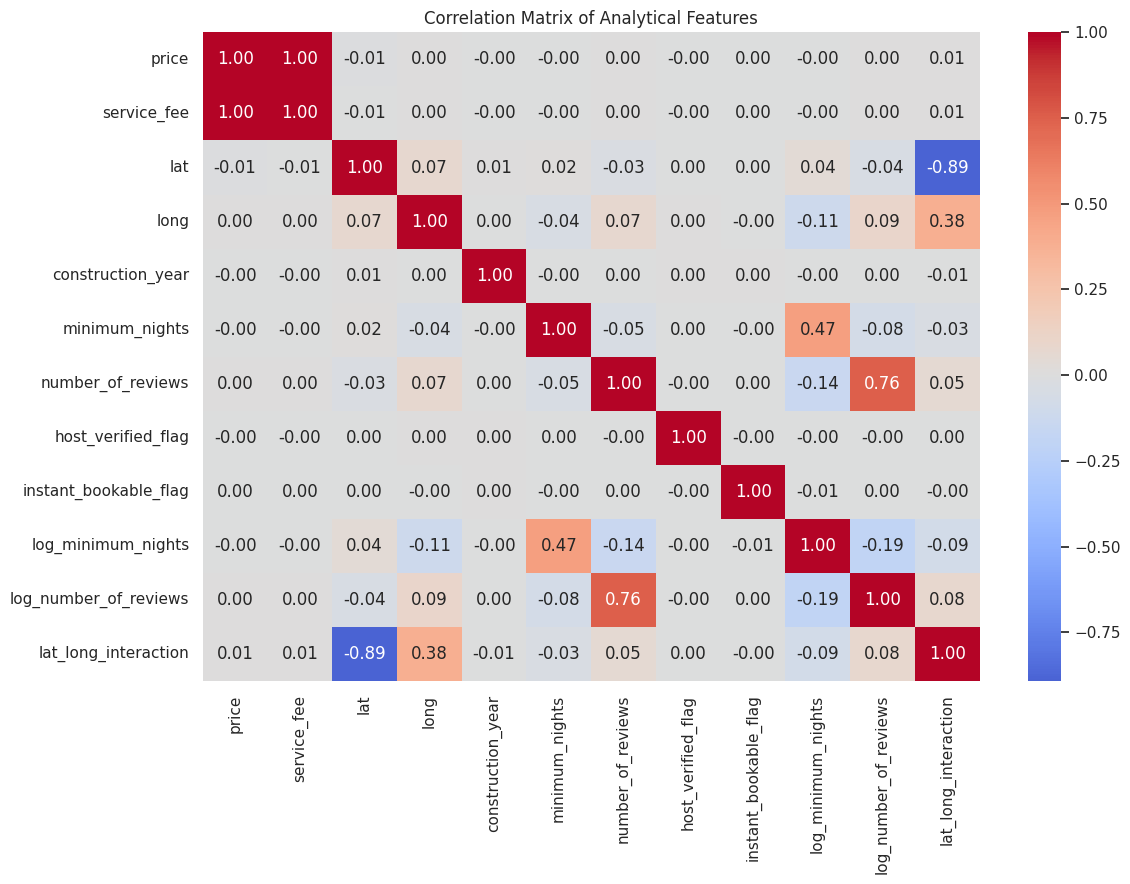

In [53]:
fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=ax,
)

ax.set_title("Correlation Matrix of Analytical Features")

plt.tight_layout()
plt.show()

In [54]:
# ============================================================
# 33. CAPSTONE DATASET SUMMARY
# ============================================================

capstone_summary = pd.Series({
    "Observations": len(analysis_df),
    "Variables": analysis_df.shape[1],
    "Mean price": analysis_df["price"].mean(),
    "Median price": analysis_df["price"].median(),
    "Price standard deviation": analysis_df["price"].std(),
    "Minimum price": analysis_df["price"].min(),
    "Maximum price": analysis_df["price"].max(),
    "Unique neighbourhood groups":
        analysis_df["neighbourhood_group"].nunique(),
    "Unique room types":
        analysis_df["room_type"].nunique(),
})

display(
    capstone_summary.to_frame("Value").round(3)
)

,Value
Observations,"97,794.0000"
Variables,22.0000
Mean price,625.4650
Median price,625.0000
Price standard deviation,331.7530
Minimum price,50.0000
Maximum price,"1,200.0000"
Unique neighbourhood groups,5.0000
Unique room types,4.0000


In [61]:
# ============================================================
# 34. PRICE-CORRELATION RANKING
# ============================================================

price_correlations = (
    correlation_matrix["price"]
    .drop("price")
    .sort_values(
        key=lambda s: s.abs(),
        ascending=False
    )
)

price_correlation_table = (
    price_correlations
    .rename("correlation_with_price")
    .to_frame()
)

display(
    price_correlation_table.style.format(
        "{:.4f}"
    )
)

,correlation_with_price
service_fee,0.9987
lat_long_interaction,0.0063
lat,-0.0056
number_of_reviews,0.0049
log_number_of_reviews,0.0048
host_verified_flag,-0.0046
log_minimum_nights,-0.0040
construction_year,-0.0039
minimum_nights,-0.0027
long,0.0026


In [62]:
# ============================================================
# 35. UNSUPERVISED LEARNING — K-MEANS PREPARATION
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)
from sklearn.decomposition import PCA

CLUSTER_FEATURES = [
    "price",
    "service_fee",
    "minimum_nights",
    "number_of_reviews",
]

cluster_data = (
    analysis_df[CLUSTER_FEATURES]
    .astype(np.float32)
    .copy()
)

cluster_scaler = StandardScaler()

cluster_matrix = cluster_scaler.fit_transform(
    cluster_data
).astype(np.float32)

print(
    f"Clustering observations : {cluster_matrix.shape[0]:,}"
)
print(
    f"Clustering features     : {cluster_matrix.shape[1]}"
)
print(
    f"Features                : {CLUSTER_FEATURES}"
)

Clustering observations : 97,794
Clustering features     : 4
Features                : ['price', 'service_fee', 'minimum_nights', 'number_of_reviews']


In [63]:
# ============================================================
# 36. K-MEANS ELBOW ANALYSIS
# ============================================================

cluster_candidates = range(2, 9)

elbow_results = []

for k in cluster_candidates:
    estimator = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
        algorithm="lloyd",
    )

    estimator.fit(cluster_matrix)

    elbow_results.append({
        "k": k,
        "inertia": estimator.inertia_,
    })

elbow_df = pd.DataFrame(elbow_results)

display(elbow_df.round(2))

,k,inertia
0,2,"245,037.5600"
1,3,"191,493.4500"
2,4,"142,866.3800"
3,5,"117,117.4100"
4,6,"95,567.8100"
5,7,"84,534.8500"
6,8,"73,912.5600"


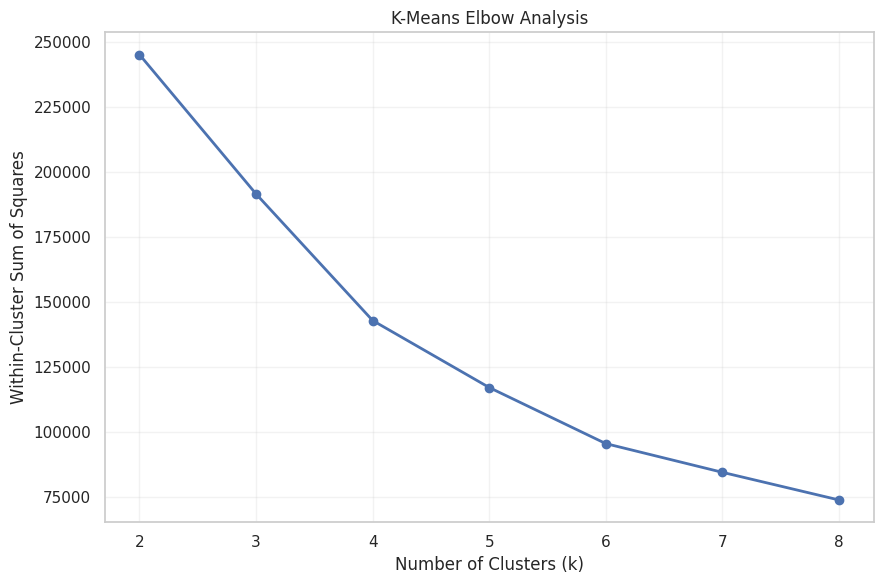

In [64]:
# ============================================================
# 36.1. ELBOW CURVE
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    elbow_df["k"],
    elbow_df["inertia"],
    marker="o",
    linewidth=2,
)

ax.set_title("K-Means Elbow Analysis")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Within-Cluster Sum of Squares")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [65]:
# ============================================================
# 37. CLUSTER VALIDATION
# ============================================================

rng = np.random.default_rng(RANDOM_STATE)

SILHOUETTE_SAMPLE_SIZE = min(
    20_000,
    len(cluster_matrix)
)

sample_indices = rng.choice(
    len(cluster_matrix),
    size=SILHOUETTE_SAMPLE_SIZE,
    replace=False,
)

cluster_sample = cluster_matrix[
    sample_indices
]

cluster_validation = []

for k in cluster_candidates:

    estimator = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
        algorithm="lloyd",
    )

    labels = estimator.fit_predict(
        cluster_matrix
    )

    sample_labels = labels[
        sample_indices
    ]

    cluster_validation.append({
        "k": k,
        "silhouette": silhouette_score(
            cluster_sample,
            sample_labels
        ),
        "calinski_harabasz": calinski_harabasz_score(
            cluster_matrix,
            labels
        ),
        "davies_bouldin": davies_bouldin_score(
            cluster_matrix,
            labels
        ),
    })

cluster_validation_df = pd.DataFrame(
    cluster_validation
)

display(
    cluster_validation_df.round(4)
)

,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.4611,"58,323.6172",0.8750
1,3,0.4920,"50,985.9141",0.7804
2,4,0.4940,"56,654.4531",0.6616
3,5,0.4051,"57,207.5977",0.7352
4,6,0.4123,"60,495.4414",0.6995
5,7,0.4183,"59,118.3438",0.7745
6,8,0.4261,"59,962.2930",0.6961


In [66]:
# ============================================================
# 38. FINAL K-MEANS SEGMENTATION
# ============================================================

FINAL_K = 2

kmeans_model = KMeans(
    n_clusters=FINAL_K,
    init="k-means++",
    n_init=20,
    max_iter=300,
    random_state=RANDOM_STATE,
    algorithm="lloyd",
)

analysis_df["cluster"] = (
    kmeans_model.fit_predict(
        cluster_matrix
    )
)

cluster_counts = (
    analysis_df["cluster"]
    .value_counts()
    .sort_index()
    .rename("listing_count")
    .to_frame()
)

display(cluster_counts)

print("✓ Final K-Means segmentation completed.")

,listing_count
cluster,
0,48672
1,49122


✓ Final K-Means segmentation completed.


In [67]:
# ============================================================
# 39. CLUSTER PROFILE
# ============================================================

cluster_profile = (
    analysis_df
    .groupby("cluster")
    .agg(
        listing_count=("price", "size"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        mean_service_fee=("service_fee", "mean"),
        mean_minimum_nights=("minimum_nights", "mean"),
        mean_reviews=("number_of_reviews", "mean"),
    )
    .sort_values(
        "mean_price",
        ascending=False
    )
)

display(
    cluster_profile.round(2)
)

,listing_count,mean_price,median_price,mean_service_fee,mean_minimum_nights,mean_reviews
cluster,,,,,,
0,48672,913.7300,914.0000,182.5800,8.1300,27.5200
1,49122,339.8400,341.0000,68.0900,8.2200,27.3700


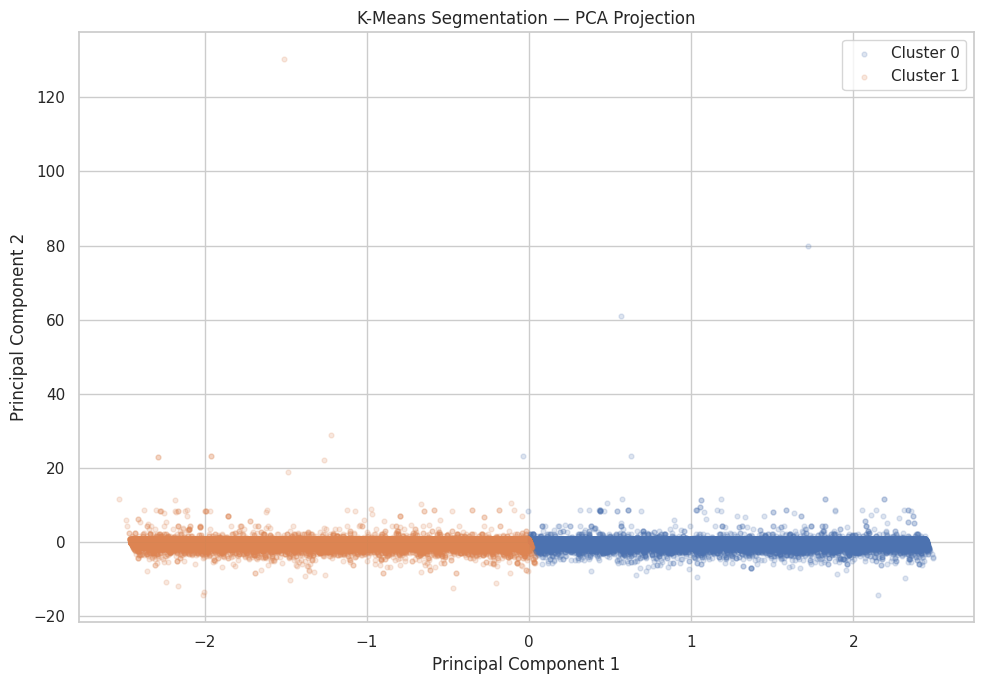

Explained variance by PC1 + PC2: 76.20%


In [68]:
# ============================================================
# 40. PCA CLUSTER VISUALIZATION
# ============================================================

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)

cluster_pca = pca.fit_transform(
    cluster_matrix
)

pca_df = pd.DataFrame({
    "PC1": cluster_pca[:, 0],
    "PC2": cluster_pca[:, 1],
    "cluster": analysis_df["cluster"].to_numpy(),
})

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in sorted(
    pca_df["cluster"].unique()
):

    subset = pca_df.loc[
        pca_df["cluster"] == cluster_id
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.18,
        s=12,
        label=f"Cluster {cluster_id}",
    )

ax.set_title(
    "K-Means Segmentation — PCA Projection"
)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.legend()

plt.tight_layout()
plt.show()

print(
    f"Explained variance by PC1 + PC2: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

In [72]:
# ============================================================
# 41. SUPERVISED LEARNING FEATURE SPECIFICATION
# ============================================================

PREDICTIVE_FEATURES = [
    "host_identity_verified",
    "neighbourhood_group",
    "neighbourhood",
    "lat",
    "long",
    "instant_bookable_flag",
    "cancellation_policy",
    "room_type",
    "construction_year",
    "minimum_nights",
    "number_of_reviews",
]

TARGET = "price"

X = analysis_df.loc[
    :, PREDICTIVE_FEATURES
].copy()

y = analysis_df.loc[
    :, TARGET
].astype(np.float32)

CATEGORICAL_FEATURES = [
    "host_identity_verified",
    "neighbourhood_group",
    "neighbourhood",
    "cancellation_policy",
    "room_type",
]

NUMERICAL_FEATURES = [
    "lat",
    "long",
    "instant_bookable_flag",
    "construction_year",
    "minimum_nights",
    "number_of_reviews",
]

assert set(PREDICTIVE_FEATURES) == (
    set(CATEGORICAL_FEATURES)
    | set(NUMERICAL_FEATURES)
)

print("Predictive feature specification")
print("=" * 60)

print(f"Predictors : {len(PREDICTIVE_FEATURES)}")
print(f"Target     : {TARGET}")
print(f"X shape    : {X.shape}")
print(f"y shape    : {y.shape}")

print("\nNumerical features:")
print(*NUMERICAL_FEATURES, sep="\n")

print("\nCategorical features:")
print(*CATEGORICAL_FEATURES, sep="\n")

Predictive feature specification
Predictors : 11
Target     : price
X shape    : (97794, 11)
y shape    : (97794,)

Numerical features:
lat
long
instant_bookable_flag
construction_year
minimum_nights
number_of_reviews

Categorical features:
host_identity_verified
neighbourhood_group
neighbourhood
cancellation_policy
room_type


In [73]:
# ============================================================
# 42. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train_full, X_test, y_train_full, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
    )
)

X_train, X_val, y_train, y_val = (
    train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.10,
        random_state=RANDOM_STATE,
    )
)

print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Test       : {X_test.shape}")

Training   : (70411, 11)
Validation : (7824, 11)
Test       : (19559, 11)


In [74]:
# ============================================================
# 43. SUPERVISED PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            NUMERICAL_FEATURES,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                dtype=np.float32,
            ),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train_processed = preprocessor.fit_transform(
    X_train
)

X_val_processed = preprocessor.transform(
    X_val
)

X_test_processed = preprocessor.transform(
    X_test
)

X_train_processed = np.asarray(
    X_train_processed,
    dtype=np.float32
)

X_val_processed = np.asarray(
    X_val_processed,
    dtype=np.float32
)

X_test_processed = np.asarray(
    X_test_processed,
    dtype=np.float32
)

y_train = np.asarray(
    y_train,
    dtype=np.float32
)

y_val = np.asarray(
    y_val,
    dtype=np.float32
)

y_test = np.asarray(
    y_test,
    dtype=np.float32
)

print(f"Processed training   : {X_train_processed.shape}")
print(f"Processed validation : {X_val_processed.shape}")
print(f"Processed test       : {X_test_processed.shape}")

Processed training   : (70411, 246)
Processed validation : (7824, 246)
Processed test       : (19559, 246)


In [75]:
# ============================================================
# 44. PREPROCESSING INTEGRITY CHECK
# ============================================================

assert X_train_processed.shape[1] == (
    X_val_processed.shape[1]
)

assert X_train_processed.shape[1] == (
    X_test_processed.shape[1]
)

assert X_train_processed.dtype == np.float32
assert X_val_processed.dtype == np.float32
assert X_test_processed.dtype == np.float32

assert np.isfinite(
    X_train_processed
).all()

assert np.isfinite(
    X_val_processed
).all()

assert np.isfinite(
    X_test_processed
).all()

assert np.isfinite(
    y_train
).all()

assert np.isfinite(
    y_val
).all()

assert np.isfinite(
    y_test
).all()

print("=" * 60)
print("PREPROCESSING INTEGRITY CHECK")
print("=" * 60)

print(f"Model input dimensions : {X_train_processed.shape[1]}")
print(f"Training samples       : {len(X_train_processed):,}")
print(f"Validation samples     : {len(X_val_processed):,}")
print(f"Test samples           : {len(X_test_processed):,}")

print("\n✓ Preprocessing pipeline validated successfully.")

PREPROCESSING INTEGRITY CHECK
Model input dimensions : 246
Training samples       : 70,411
Validation samples     : 7,824
Test samples           : 19,559

✓ Preprocessing pipeline validated successfully.


In [76]:
# ============================================================
# 45. LINEAR REGRESSION BASELINE
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

linear_model = LinearRegression(
    fit_intercept=True
)

linear_model.fit(
    X_train_processed,
    y_train,
)

linear_predictions = linear_model.predict(
    X_test_processed
)

linear_metrics = {
    "MAE": mean_absolute_error(
        y_test,
        linear_predictions,
    ),
    "MSE": mean_squared_error(
        y_test,
        linear_predictions,
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            linear_predictions,
        )
    ),
    "R²": r2_score(
        y_test,
        linear_predictions,
    ),
}

linear_results = (
    pd.Series(
        linear_metrics,
        name="Linear Regression",
    )
    .to_frame("Value")
)

display(
    linear_results.round(4)
)

,Value
MAE,288.8822
MSE,"111,327.8906"
RMSE,333.6583
R²,-0.0023


In [77]:
# ============================================================
# 46. RANDOM FOREST REGRESSION
# ============================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model.fit(
    X_train_processed,
    y_train,
)

rf_predictions = rf_model.predict(
    X_test_processed
)

rf_metrics = {
    "MAE": mean_absolute_error(
        y_test,
        rf_predictions,
    ),
    "MSE": mean_squared_error(
        y_test,
        rf_predictions,
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            rf_predictions,
        )
    ),
    "R²": r2_score(
        y_test,
        rf_predictions,
    ),
}

rf_results = (
    pd.Series(
        rf_metrics,
        name="Random Forest",
    )
    .to_frame("Value")
)

display(
    rf_results.round(4)
)

,Value
MAE,285.9134
MSE,"109,396.5364"
RMSE,330.7515
R²,0.0151


In [78]:
# ============================================================
# 47. RANDOM FOREST CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import cross_validate

rf_cv_model = RandomForestRegressor(
    n_estimators=75,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

cv_output = cross_validate(
    rf_cv_model,
    X_train_processed,
    y_train,
    cv=5,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    return_train_score=False,
    n_jobs=-1,
)

cv_summary = pd.DataFrame({
    "R²": cv_output["test_r2"],
    "MAE": -cv_output["test_mae"],
    "RMSE": -cv_output["test_rmse"],
})

display(
    cv_summary.round(4)
)

print(
    f"Mean CV R² : "
    f"{cv_summary['R²'].mean():.4f}"
)

print(
    f"Std CV R²  : "
    f"{cv_summary['R²'].std():.4f}"
)

,R²,MAE,RMSE
0,0.0077,286.4485,331.8718
1,0.0022,287.3453,332.4567
2,0.0095,282.6066,329.2502
3,0.0086,283.9513,329.3922
4,0.0048,283.7232,329.4022


Mean CV R² : 0.0066
Std CV R²  : 0.0030


In [79]:
# ============================================================
# 48. RANDOM FOREST GENERALIZATION GAP
# ============================================================

rf_train_predictions = rf_model.predict(
    X_train_processed
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions,
)

rf_test_r2 = rf_metrics["R²"]

generalization_gap = (
    rf_train_r2 - rf_test_r2
)

rf_generalization = pd.Series({
    "Training R²": rf_train_r2,
    "Test R²": rf_test_r2,
    "Generalization gap": generalization_gap,
})

display(
    rf_generalization
    .to_frame("Value")
    .round(4)
)

,Value
Training R²,0.3898
Test R²,0.0151
Generalization gap,0.3747


In [80]:
# ============================================================
# 49. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": rf_model.feature_importances_,
    })
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    importance_df.head(20)
)

,feature,importance
0,lat,0.1882
1,long,0.1881
2,number_of_reviews,0.1539
3,construction_year,0.1331
4,minimum_nights,0.0990
5,instant_bookable_flag,0.0262
6,cancellation_policy_flexible,0.0144
7,cancellation_policy_strict,0.0142
8,cancellation_policy_moderate,0.0141
9,room_type_Private room,0.0136


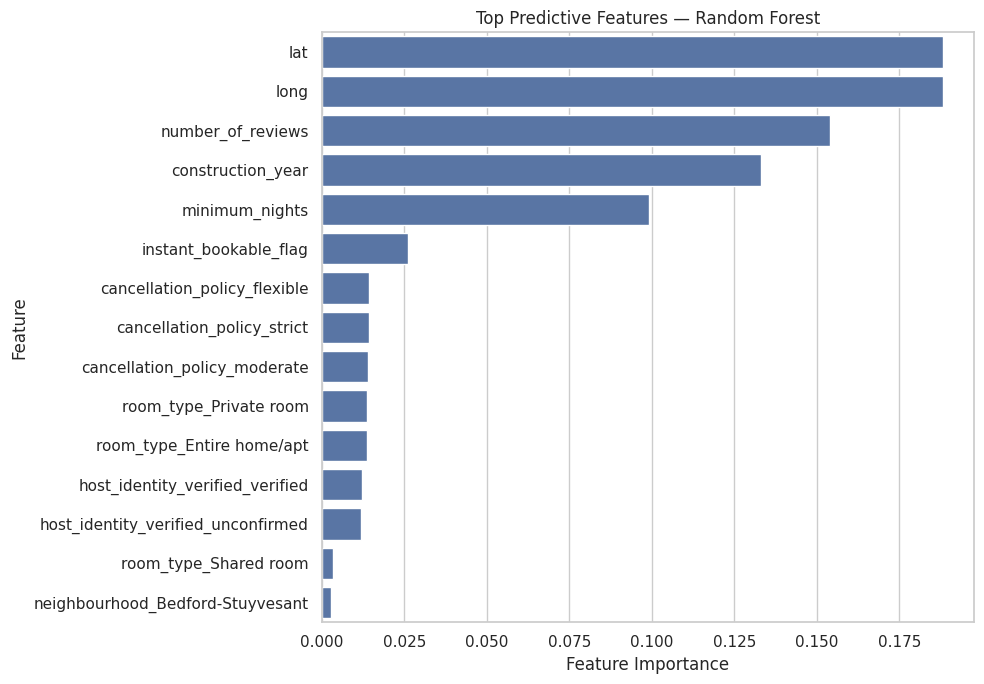

In [81]:
# ============================================================
# 49.1. TOP FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = importance_df.head(15)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    ax=ax,
)

ax.set_title(
    "Top Predictive Features — Random Forest"
)

ax.set_xlabel(
    "Feature Importance"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

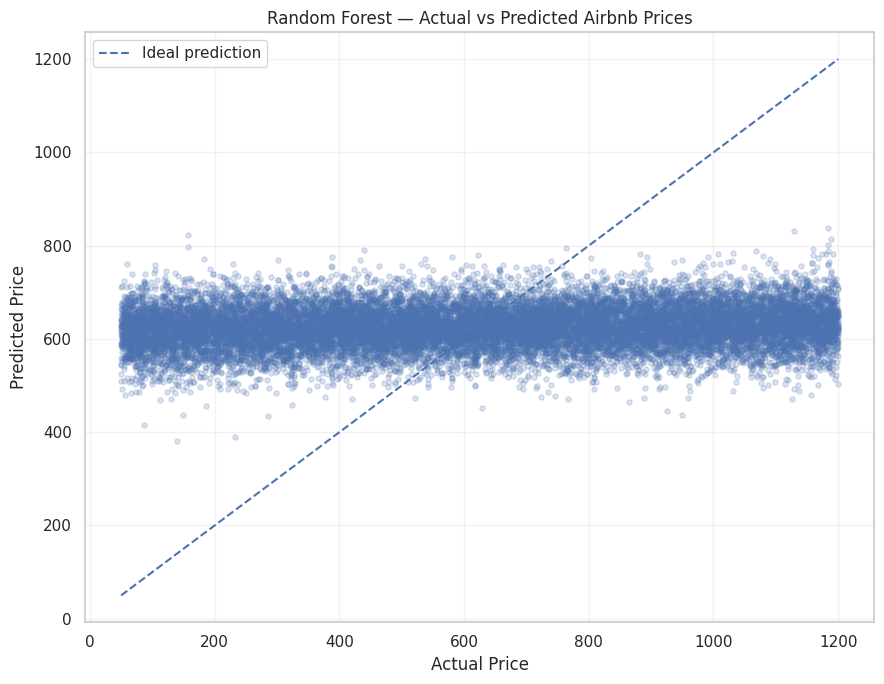

In [82]:
# ============================================================
# 50. RANDOM FOREST ACTUAL VS PREDICTED
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.scatter(
    y_test,
    rf_predictions,
    alpha=0.20,
    s=14,
)

reference_min = min(
    y_test.min(),
    rf_predictions.min(),
)

reference_max = max(
    y_test.max(),
    rf_predictions.max(),
)

ax.plot(
    [reference_min, reference_max],
    [reference_min, reference_max],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction",
)

ax.set_title(
    "Random Forest — Actual vs Predicted Airbnb Prices"
)

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

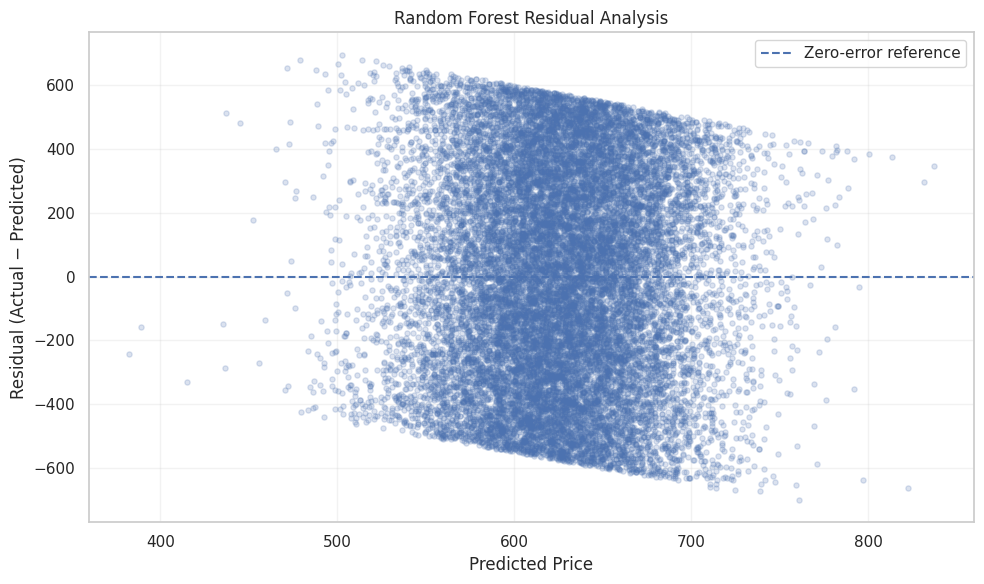

In [83]:
# ============================================================
# 51. RANDOM FOREST RESIDUAL ANALYSIS
# ============================================================

rf_residuals = (
    y_test - rf_predictions
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    rf_predictions,
    rf_residuals,
    alpha=0.20,
    s=14,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Zero-error reference",
)

ax.set_title(
    "Random Forest Residual Analysis"
)

ax.set_xlabel(
    "Predicted Price"
)

ax.set_ylabel(
    "Residual (Actual − Predicted)"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [84]:
# ============================================================
# 52. CAPSTONE DEEP NEURAL NETWORK
# ============================================================

from tensorflow import keras
from tensorflow.keras import layers

keras.utils.set_random_seed(
    RANDOM_STATE
)


def build_capstone_dnn(
    input_dim: int,
    learning_rate: float = 1e-3,
) -> keras.Model:

    inputs = keras.Input(
        shape=(input_dim,),
        name="airbnb_features",
    )

    x = layers.Dense(
        256,
        kernel_initializer="he_normal",
        name="dense_256",
    )(inputs)

    x = layers.BatchNormalization(
        name="batch_norm_256"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_256"
    )(x)

    x = layers.Dropout(
        0.20,
        name="dropout_256"
    )(x)

    x = layers.Dense(
        128,
        kernel_initializer="he_normal",
        name="dense_128",
    )(x)

    x = layers.BatchNormalization(
        name="batch_norm_128"
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_128"
    )(x)

    x = layers.Dropout(
        0.15,
        name="dropout_128"
    )(x)

    x = layers.Dense(
        64,
        kernel_initializer="he_normal",
        name="dense_64",
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_64"
    )(x)

    x = layers.Dense(
        32,
        kernel_initializer="he_normal",
        name="dense_32",
    )(x)

    x = layers.Activation(
        "relu",
        name="relu_32"
    )(x)

    outputs = layers.Dense(
        1,
        activation="linear",
        name="price_prediction",
    )(x)

    model = keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="airbnb_capstone_dnn",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0,
        ),
        loss=keras.losses.Huber(),
        metrics=[
            keras.metrics.MeanAbsoluteError(
                name="mae"
            ),
            keras.metrics.RootMeanSquaredError(
                name="rmse"
            ),
        ],
    )

    return model


dnn_model = build_capstone_dnn(
    input_dim=X_train_processed.shape[1]
)

dnn_model.summary()

Model: "airbnb_capstone_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ airbnb_features (InputLayer)    │ (None, 246)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │        63,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_256                  │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_256 (Activation)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_256 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_128                  │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_128 (Activation)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_128 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_64 (Activation)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_32 (Activation)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ price_prediction (Dense)        │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,033 (422.00 KB)

 Trainable params: 107,265 (419.00 KB)

 Non-trainable params: 768 (3.00 KB)

In [85]:
# ============================================================
# 53. DNN TRAINING
# ============================================================

dnn_checkpoint = (
    MODEL_DIR /
    "week6_capstone_dnn_best.keras"
)

dnn_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=7,
        min_delta=1e-4,
        restore_best_weights=True,
        verbose=1,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),

    keras.callbacks.ModelCheckpoint(
        filepath=str(dnn_checkpoint),
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

dnn_history = dnn_model.fit(
    X_train_processed,
    y_train,
    validation_data=(
        X_val_processed,
        y_val,
    ),
    epochs=40,
    batch_size=256,
    callbacks=dnn_callbacks,
    verbose=1,
)

Epoch 1/40
270/276 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 506.5791 - mae: 507.0789 - rmse: 598.0806
Epoch 1: val_loss improved from None to 297.95505, saving model to /content/capstone_artifacts/models/week6_capstone_dnn_best.keras

Epoch 1: finished saving model to /content/capstone_artifacts/models/week6_capstone_dnn_best.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 391.9626 - mae: 392.4623 - rmse: 481.5258 - val_loss: 297.9550 - val_mae: 298.4546 - val_rmse: 353.7315 - learning_rate: 0.0010
Epoch 2/40
273/276 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 288.8469 - mae: 289.3466 - rmse: 336.4281
Epoch 2: val_loss improved from 297.95505 to 286.92880, saving model to /content/capstone_artifacts/models/week6_capstone_dnn_best.keras

Epoch 2: finished saving model to /content/capstone_artifacts/models/week6_capstone_dnn_best.keras
276/276 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 288.1059 - mae: 288.6055 - rmse: 335.7169 - val_loss: 286.9288 - val_mae: 287.4283 - val_rmse: 3

In [86]:
# ============================================================
# 54. DNN TEST EVALUATION
# ============================================================

dnn_predictions = (
    dnn_model.predict(
        X_test_processed,
        batch_size=1024,
        verbose=0,
    )
    .ravel()
)

dnn_metrics = {
    "MAE": mean_absolute_error(
        y_test,
        dnn_predictions,
    ),
    "MSE": mean_squared_error(
        y_test,
        dnn_predictions,
    ),
    "RMSE": np.sqrt(
        mean_squared_error(
            y_test,
            dnn_predictions,
        )
    ),
    "R²": r2_score(
        y_test,
        dnn_predictions,
    ),
}

display(
    pd.Series(
        dnn_metrics,
        name="Capstone DNN",
    )
    .to_frame("Value")
    .round(4)
)

,Value
MAE,290.9321
MSE,"113,517.2266"
RMSE,336.9232
R²,-0.0220


In [87]:
# ============================================================
# 55. DNN TRAINING HISTORY
# ============================================================

dnn_history_df = (
    pd.DataFrame(dnn_history.history)
)

dnn_history_df.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(dnn_history_df) + 1
    ),
)

best_epoch_idx = (
    dnn_history_df["val_loss"]
    .idxmin()
)

best_epoch = int(
    dnn_history_df.loc[
        best_epoch_idx,
        "epoch"
    ]
)

print(
    f"Training epochs completed: "
    f"{len(dnn_history_df)}"
)

print(
    f"Best validation epoch: "
    f"{best_epoch}"
)

print(
    f"Best validation loss: "
    f"{dnn_history_df.loc[best_epoch_idx, 'val_loss']:.4f}"
)

Training epochs completed: 10
Best validation epoch: 3
Best validation loss: 285.5533


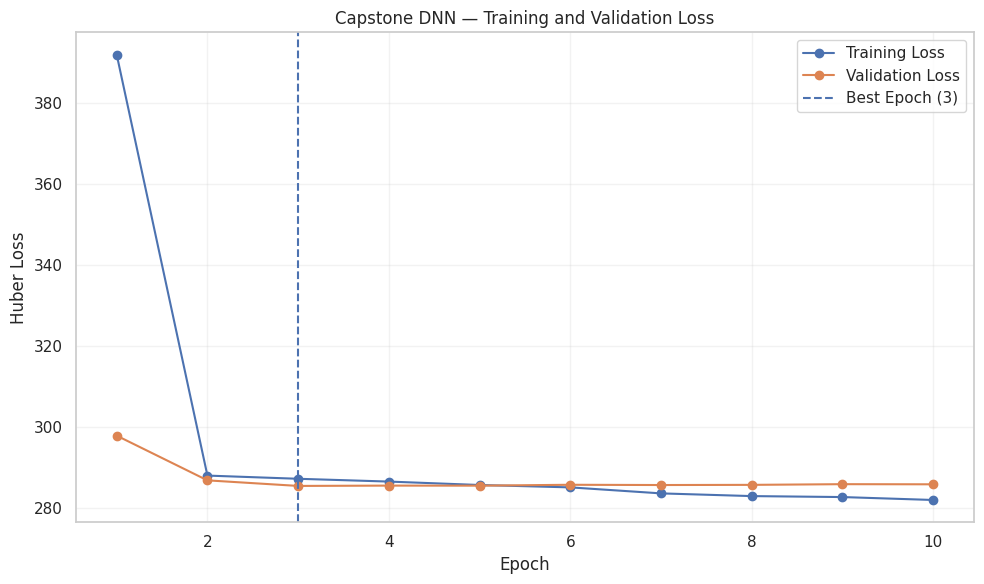

In [88]:
# ============================================================
# 55.1. DNN LOSS CURVE
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.plot(
    dnn_history_df["epoch"],
    dnn_history_df["loss"],
    marker="o",
    label="Training Loss",
)

ax.plot(
    dnn_history_df["epoch"],
    dnn_history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)

ax.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_epoch})",
)

ax.set_title(
    "Capstone DNN — Training and Validation Loss"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Huber Loss")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [89]:
# ============================================================
# 56. CONSOLIDATED MODEL BENCHMARK
# ============================================================

final_benchmark = pd.DataFrame.from_dict(
    {
        "Linear Regression": linear_metrics,
        "Random Forest": rf_metrics,
        "Capstone DNN": dnn_metrics,
    },
    orient="index",
)

display(
    final_benchmark.round(4)
)

,MAE,MSE,RMSE,R²
Linear Regression,288.8822,"111,327.8906",333.6583,-0.0023
Random Forest,285.9134,"109,396.5364",330.7515,0.0151
Capstone DNN,290.9321,"113,517.2266",336.9232,-0.0220


In [90]:
# ============================================================
# 57. RANDOM FOREST GENERALIZATION ANALYSIS
# ============================================================

rf_train_predictions = rf_model.predict(
    X_train_processed
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_predictions
)

rf_test_r2 = rf_metrics["R²"]

rf_generalization = pd.Series(
    {
        "Training R²": rf_train_r2,
        "Test R²": rf_test_r2,
        "Generalization gap":
            rf_train_r2 - rf_test_r2,
    },
    name="Value"
)

display(
    rf_generalization
    .to_frame()
    .round(4)
)

,Value
Training R²,0.3898
Test R²,0.0151
Generalization gap,0.3747


In [91]:
# ============================================================
# 58. DNN GENERALIZATION ANALYSIS
# ============================================================

dnn_train_predictions = (
    dnn_model.predict(
        X_train_processed,
        batch_size=1024,
        verbose=0,
    )
    .ravel()
)

dnn_train_r2 = r2_score(
    y_train,
    dnn_train_predictions
)

dnn_test_r2 = dnn_metrics["R²"]

dnn_generalization = pd.Series(
    {
        "Training R²": dnn_train_r2,
        "Test R²": dnn_test_r2,
        "Generalization gap":
            dnn_train_r2 - dnn_test_r2,
    },
    name="Value"
)

display(
    dnn_generalization
    .to_frame()
    .round(4)
)

,Value
Training R²,-0.0013
Test R²,-0.0220
Generalization gap,0.0208


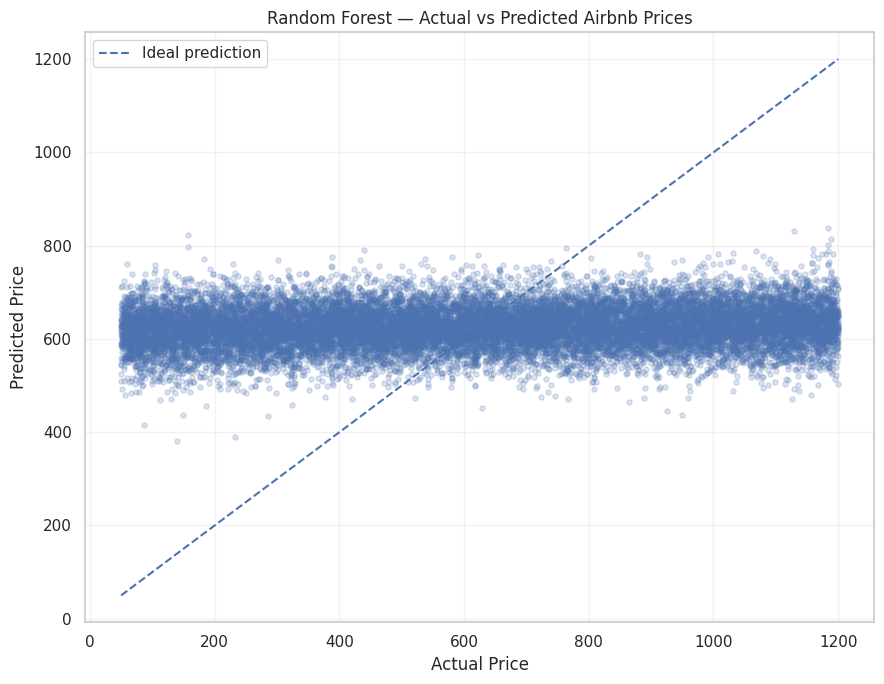

In [92]:
# ============================================================
# 59. RANDOM FOREST — ACTUAL VS PREDICTED
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.scatter(
    y_test,
    rf_predictions,
    alpha=0.20,
    s=14,
)

lower = min(
    y_test.min(),
    rf_predictions.min(),
)

upper = max(
    y_test.max(),
    rf_predictions.max(),
)

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction"
)

ax.set_title(
    "Random Forest — Actual vs Predicted Airbnb Prices"
)

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

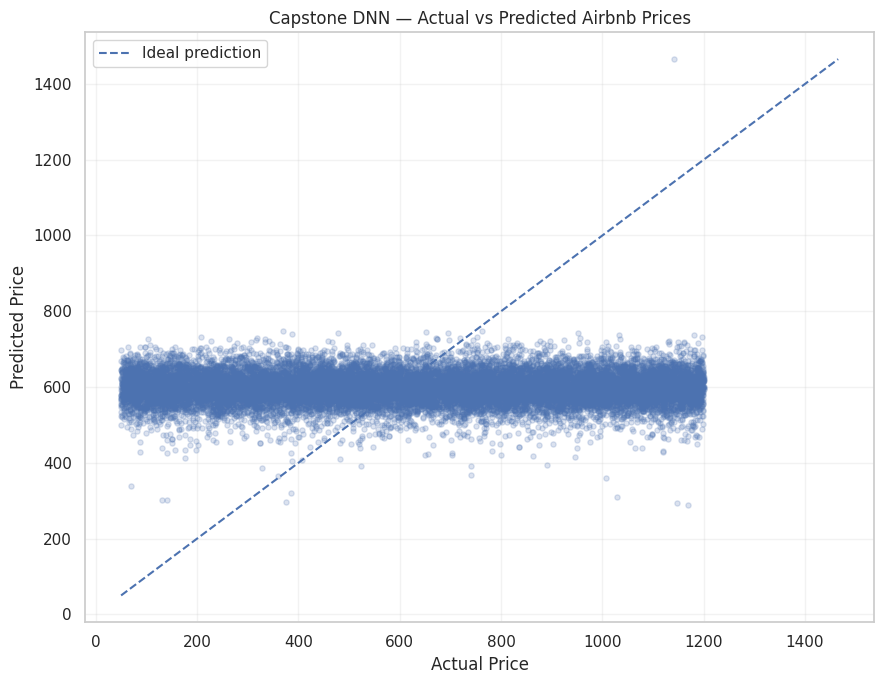

In [93]:
# ============================================================
# 59.1. DNN — ACTUAL VS PREDICTED
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.scatter(
    y_test,
    dnn_predictions,
    alpha=0.20,
    s=14,
)

lower = min(
    y_test.min(),
    dnn_predictions.min(),
)

upper = max(
    y_test.max(),
    dnn_predictions.max(),
)

ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction"
)

ax.set_title(
    "Capstone DNN — Actual vs Predicted Airbnb Prices"
)

ax.set_xlabel("Actual Price")
ax.set_ylabel("Predicted Price")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

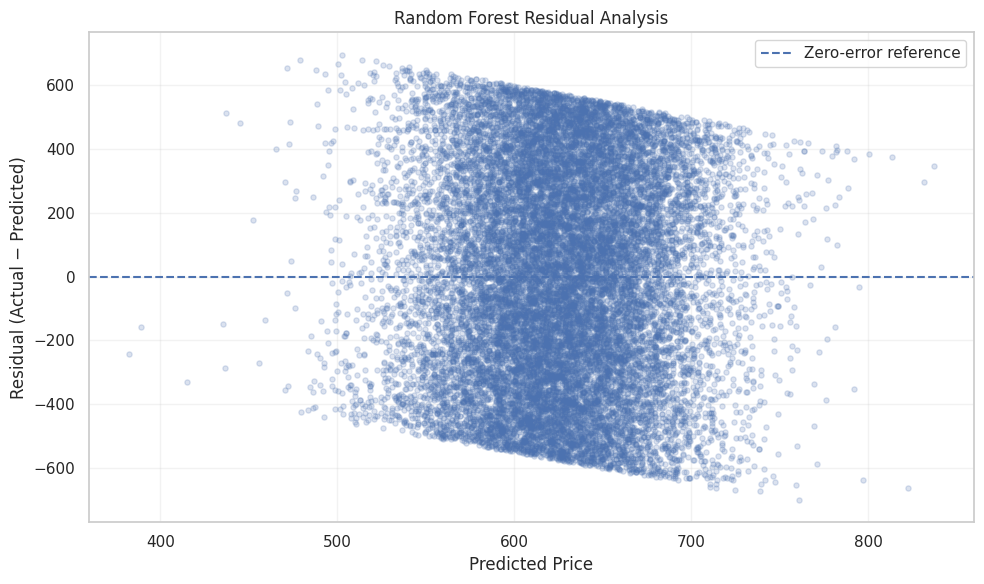

In [94]:
# ============================================================
# 60. RANDOM FOREST RESIDUAL ANALYSIS
# ============================================================

rf_residuals = (
    y_test - rf_predictions
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    rf_predictions,
    rf_residuals,
    alpha=0.20,
    s=14,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Zero-error reference"
)

ax.set_title(
    "Random Forest Residual Analysis"
)

ax.set_xlabel("Predicted Price")
ax.set_ylabel(
    "Residual (Actual − Predicted)"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

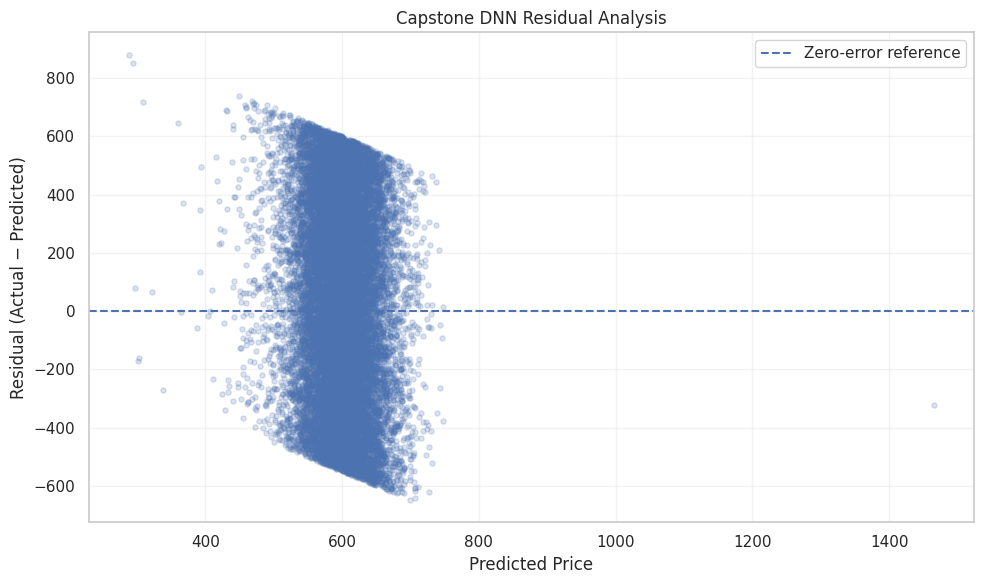

In [95]:
# ============================================================
# 60.1. DNN RESIDUAL ANALYSIS
# ============================================================

dnn_residuals = (
    y_test - dnn_predictions
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.scatter(
    dnn_predictions,
    dnn_residuals,
    alpha=0.20,
    s=14,
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Zero-error reference"
)

ax.set_title(
    "Capstone DNN Residual Analysis"
)

ax.set_xlabel("Predicted Price")
ax.set_ylabel(
    "Residual (Actual − Predicted)"
)

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

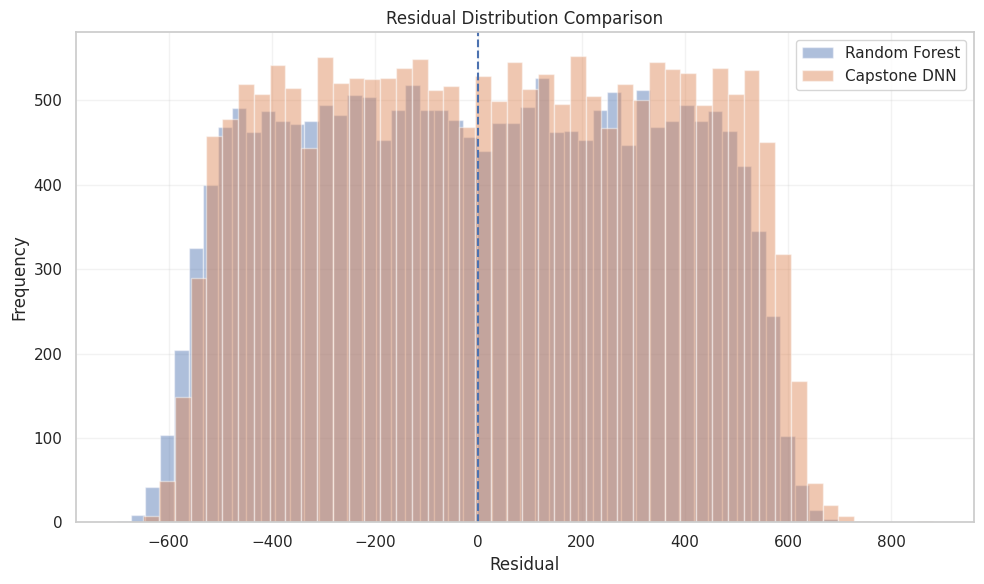

In [96]:
# ============================================================
# 61. RESIDUAL DISTRIBUTIONS
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.hist(
    rf_residuals,
    bins=50,
    alpha=0.45,
    label="Random Forest"
)

ax.hist(
    dnn_residuals,
    bins=50,
    alpha=0.45,
    label="Capstone DNN"
)

ax.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
)

ax.set_title(
    "Residual Distribution Comparison"
)

ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")

ax.legend()
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

In [97]:
# ============================================================
# 62. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance_df = (
    pd.DataFrame(
        {
            "feature": feature_names,
            "importance":
                rf_model.feature_importances_,
        }
    )
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_df.head(20)
)

,feature,importance
0,lat,0.1882
1,long,0.1881
2,number_of_reviews,0.1539
3,construction_year,0.1331
4,minimum_nights,0.0990
5,instant_bookable_flag,0.0262
6,cancellation_policy_flexible,0.0144
7,cancellation_policy_strict,0.0142
8,cancellation_policy_moderate,0.0141
9,room_type_Private room,0.0136


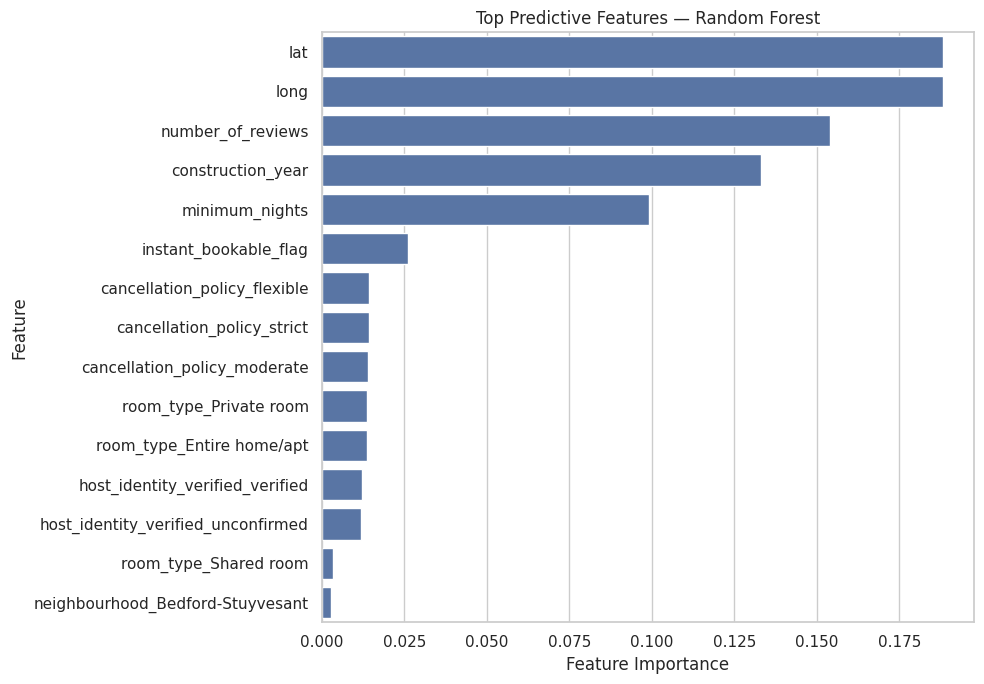

In [98]:
# ============================================================
# 62.1. TOP 15 FEATURE IMPORTANCES
# ============================================================

top_features = importance_df.head(15)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    ax=ax
)

ax.set_title(
    "Top Predictive Features — Random Forest"
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
plt.show()

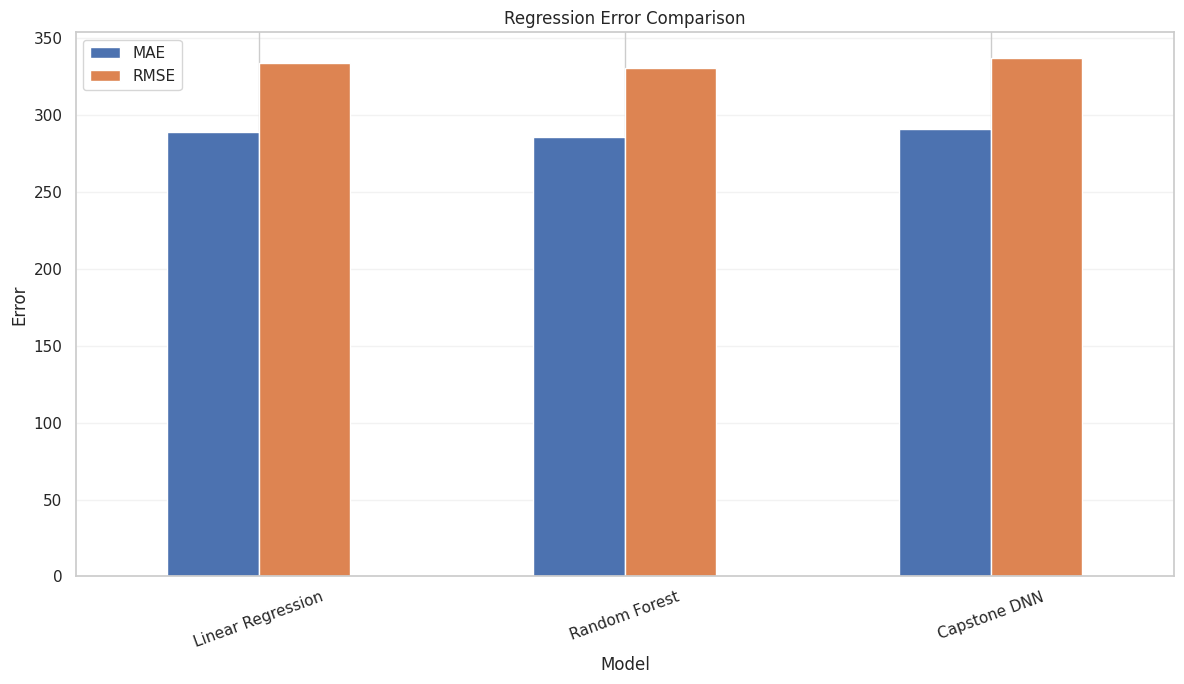

In [99]:
# ============================================================
# 63. MODEL PERFORMANCE COMPARISON
# ============================================================

metric_plot_df = final_benchmark[
    ["MAE", "RMSE", "R²"]
].copy()

fig, ax = plt.subplots(
    figsize=(12, 7)
)

metric_plot_df[
    ["MAE", "RMSE"]
].plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Regression Error Comparison"
)

ax.set_xlabel("Model")
ax.set_ylabel("Error")

ax.tick_params(
    axis="x",
    rotation=20
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

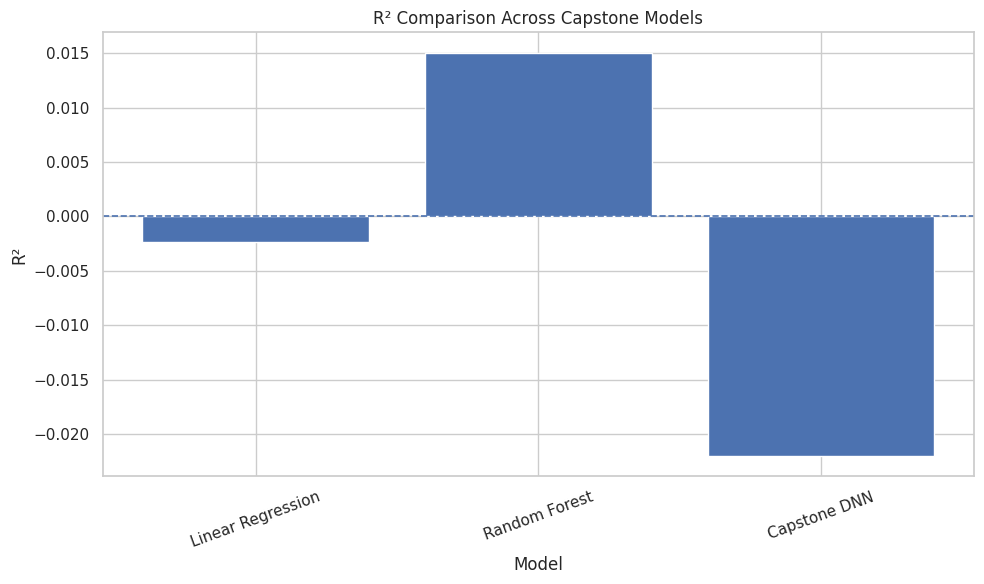

In [100]:
# ============================================================
# 63.1. R² COMPARISON
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 6)
)

ax.bar(
    final_benchmark.index,
    final_benchmark["R²"]
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2,
)

ax.set_title(
    "R² Comparison Across Capstone Models"
)

ax.set_xlabel("Model")
ax.set_ylabel("R²")

ax.tick_params(
    axis="x",
    rotation=20
)

plt.tight_layout()
plt.show()

In [101]:
# ============================================================
# 64. RELATIVE PERFORMANCE ANALYSIS
# ============================================================

baseline_mae = linear_metrics["MAE"]
baseline_rmse = linear_metrics["RMSE"]

comparison_analysis = final_benchmark.copy()

comparison_analysis[
    "MAE change vs Linear (%)"
] = (
    (comparison_analysis["MAE"] - baseline_mae)
    / baseline_mae
    * 100
)

comparison_analysis[
    "RMSE change vs Linear (%)"
] = (
    (comparison_analysis["RMSE"] - baseline_rmse)
    / baseline_rmse
    * 100
)

display(
    comparison_analysis.round(4)
)

,MAE,MSE,RMSE,R²,MAE change vs Linear (%),RMSE change vs Linear (%)
Linear Regression,288.8822,"111,327.8906",333.6583,-0.0023,0.0000,0.0000
Random Forest,285.9134,"109,396.5364",330.7515,0.0151,-1.0277,-0.8712
Capstone DNN,290.9321,"113,517.2266",336.9232,-0.0220,0.7096,0.9785


In [102]:
# ============================================================
# 65. FINAL QUANTITATIVE FINDINGS
# ============================================================

rf_mae = rf_metrics["MAE"]
rf_rmse = rf_metrics["RMSE"]
rf_r2 = rf_metrics["R²"]

dnn_mae = dnn_metrics["MAE"]
dnn_rmse = dnn_metrics["RMSE"]
dnn_r2 = dnn_metrics["R²"]

findings = {
    "Dataset observations":
        len(analysis_df),

    "Predictive input dimensions":
        X_train_processed.shape[1],

    "Number of clusters":
        FINAL_K,

    "Random Forest MAE":
        rf_mae,

    "Random Forest RMSE":
        rf_rmse,

    "Random Forest R²":
        rf_r2,

    "DNN MAE":
        dnn_mae,

    "DNN RMSE":
        dnn_rmse,

    "DNN R²":
        dnn_r2,

    "Random Forest vs Linear MAE change (%)":
        (
            (rf_mae - linear_metrics["MAE"])
            / linear_metrics["MAE"]
            * 100
        ),

    "Random Forest vs Linear RMSE change (%)":
        (
            (rf_rmse - linear_metrics["RMSE"])
            / linear_metrics["RMSE"]
            * 100
        ),
}

display(
    pd.Series(findings, name="Value")
    .to_frame()
    .round(4)
)

,Value
Dataset observations,"97,794.0000"
Predictive input dimensions,246.0000
Number of clusters,2.0000
Random Forest MAE,285.9134
Random Forest RMSE,330.7515
Random Forest R²,0.0151
DNN MAE,290.9321
DNN RMSE,336.9232
DNN R²,-0.0220
Random Forest vs Linear MAE change (%),-1.0277


In [103]:
# ============================================================
# 66. FINAL CAPSTONE ARTIFACT EXPORT
# ============================================================

# Core analytical tables
final_benchmark.to_csv(
    RESULT_DIR / "final_model_comparison.csv"
)

comparison_analysis.to_csv(
    RESULT_DIR / "relative_model_analysis.csv"
)

cluster_profile.to_csv(
    RESULT_DIR / "cluster_profile.csv"
)

cluster_validation_df.to_csv(
    RESULT_DIR / "cluster_validation.csv",
    index=False
)

importance_df.to_csv(
    RESULT_DIR / "random_forest_feature_importance.csv",
    index=False
)

dnn_history_df.to_csv(
    RESULT_DIR / "dnn_training_history.csv",
    index=False
)

# Prediction outputs
prediction_results = pd.DataFrame({
    "actual_price": y_test,
    "random_forest_prediction": rf_predictions,
    "dnn_prediction": dnn_predictions,
    "rf_residual": rf_residuals,
    "dnn_residual": dnn_residuals,
})

prediction_results.to_csv(
    RESULT_DIR / "prediction_analysis.csv",
    index=False
)

# Final cleaned analytical dataset
analysis_df.to_csv(
    ARTIFACT_DIR / "final_capstone_dataset.csv",
    index=False
)

# Model
dnn_model.save(
    MODEL_DIR / "week6_capstone_dnn.keras"
)

print("=" * 72)
print("FINAL CAPSTONE ARTIFACTS EXPORTED")
print("=" * 72)

print(f"Artifact directory : {ARTIFACT_DIR}")
print(f"Model directory    : {MODEL_DIR}")
print(f"Results directory  : {RESULT_DIR}")

FINAL CAPSTONE ARTIFACTS EXPORTED
Artifact directory : /content/capstone_artifacts
Model directory    : /content/capstone_artifacts/models
Results directory  : /content/capstone_artifacts/results
